# Individual spectrum checks

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import BoundaryNorm, Normalize
from astropy.table import Table
from astropy.io import fits
from sdss_access import Access
access = Access(release='dr19')

import paths
from utils import vac2air

plt.style.use(paths.styles / 'notebook.mplstyle')

In [3]:
mwm_sample = pd.read_csv(paths.data / 'MWM' / 'sample.csv', index_col='sdss_id')
mwm_sample

,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,catalogid25,...,Rg,orbit_flags,fe_h_corr,ce_h_corr,fe_mg_corr,mg_fe_corr,ce_mg_corr,ce_fe_corr,low_alpha,high_alpha
sdss_id,,,,,,,,,,,,,,,,,,,,,
54381959,2M00224114+5636475,421557607115380608,421557607115380608,403393455,16025,gaia_dr3_source,31,63050394783222145,4291878516,27021597851161007,...,8.590056,0.0,-0.263113,0.010890,-0.013271,0.013271,0.260731,0.274003,True,False
54381962,NaN,421557744554456064,421557744554456064,403393481,16025,tic_v8,25,27021597851161095,4291878605,27021597851161095,...,9.153462,0.0,-0.241018,0.079030,0.003839,-0.003839,0.323887,0.320048,True,False
54381968,2M00220667+5639444,421558740986710784,421558740986710784,403316795,16025,gaia_dr3_source,31,63050394783222492,4291878364,27021597851160855,...,10.254416,0.0,-0.112523,0.228345,-0.020530,0.020530,0.320339,0.340869,True,False
54381984,2M00223542+5645497,421560390254274304,421560390254274304,403393131,16025,gaia_dr3_source,31,63050394783223054,4291881586,27021597851164071,...,9.035937,0.0,0.061913,0.190950,0.048523,-0.048523,0.177560,0.129037,True,False
54382000,2M00220711+5648323,421561489765700224,421561489765700224,403317093,16025,gaia_dr3_source,31,63050394783223394,4291881416,27021597851163901,...,14.852359,0.0,-0.182748,0.012715,0.005658,-0.005658,0.201122,0.195464,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129060797,2M08543799-4600155,5331153616728690432,5331153616728690432,29951519,169169,gaia_dr3_source,31,63050395878304977,5803209549,27021599359029628,...,7.758100,0.0,-0.059793,0.246831,0.047802,-0.047802,0.354426,0.306624,True,False
129060805,2M08300191-3959403,5527814224979419776,5527814224979419776,184540591,161717,gaia_dr3_source,31,63050395950376805,5809725641,27021599365533938,...,10.770966,0.0,-0.523929,-0.496442,-0.060767,0.060767,-0.033280,0.027487,True,False
129060884,2M09110058-4849577,5326021096449688064,5326021096449688064,364057991,172356,gaia_dr3_source,31,63050395875982757,5802300216,27021599358122770,...,4.912325,0.0,-0.363648,-0.118817,-0.011611,0.011611,0.233220,0.244831,True,False


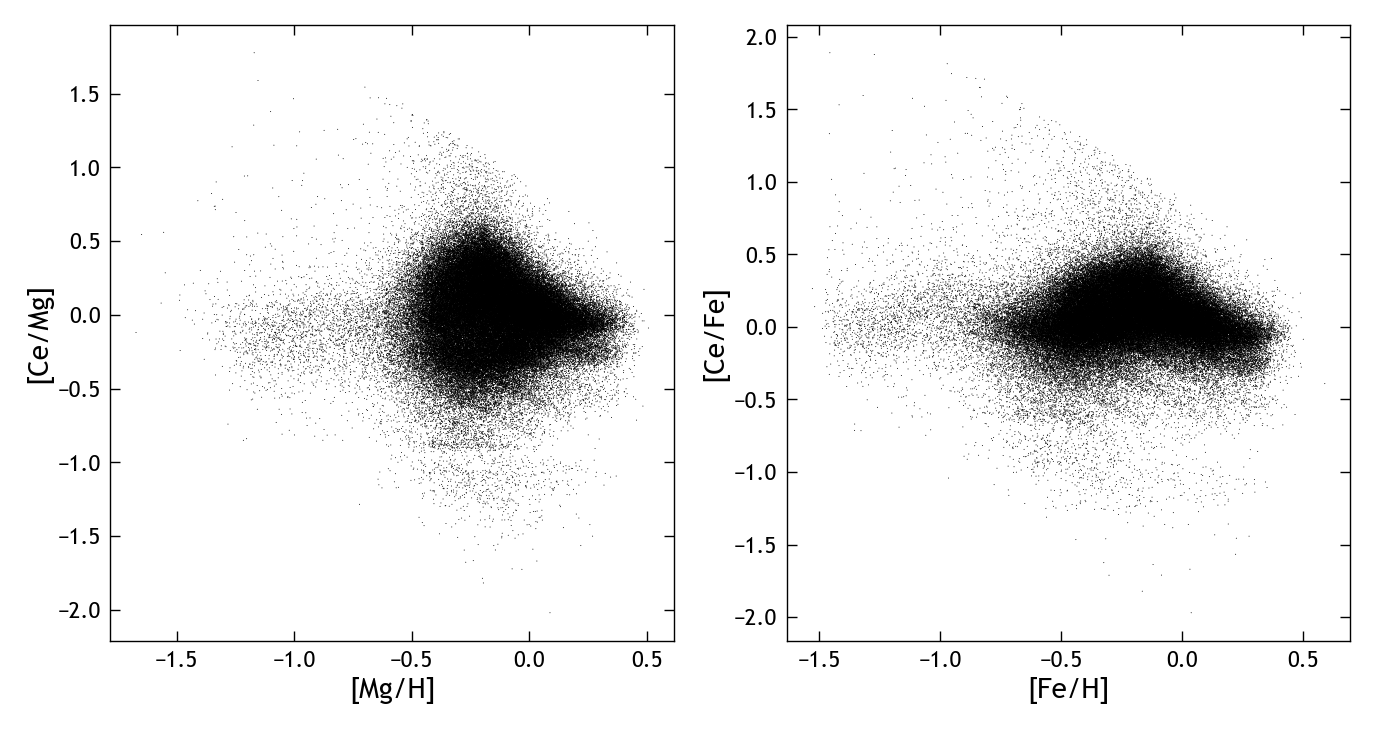

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].scatter(
    mwm_sample['mg_h'], mwm_sample['ce_mg'],
    s=0.5, marker='.', rasterized=True, edgecolor='none', c='k'
)
axs[0].set_xlabel('[Mg/H]')
axs[0].set_ylabel('[Ce/Mg]')
axs[1].scatter(
    mwm_sample['fe_h'], mwm_sample['ce_fe'],
    s=0.5, marker='.', rasterized=True, edgecolor='none', c='k'
)
axs[1].set_xlabel('[Fe/H]')
axs[1].set_ylabel('[Ce/Fe]')
plt.show()

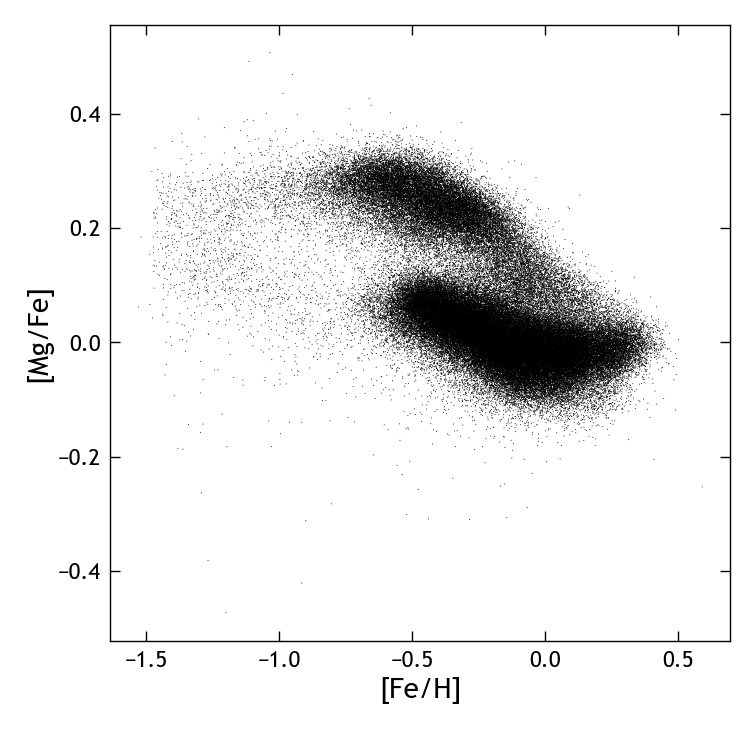

In [5]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(
    mwm_sample['fe_h'], mwm_sample['mg_fe'],
    s=0.5, marker='.', rasterized=True, edgecolor='none', c='k'
)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Mg/Fe]')
plt.show()

In [6]:
all_mwm = Table.read(paths.data / 'MWM' / 'astraAllStarASPCAP-0.6.0.fits.gz', hdu=2)

## Get a test spectrum

In [7]:
# Find star in Cunha+ (2017)
all_mwm[all_mwm['obj'] == '2M15203732-0207263']

sdss_id,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,catalogid25,catalogid31,n_associated,n_neighborhood,sdss5_target_flags,sdss4_apogee_target1_flags,sdss4_apogee_target2_flags,sdss4_apogee2_target1_flags,sdss4_apogee2_target2_flags,sdss4_apogee2_target3_flags,sdss4_apogee_member_flags,sdss4_apogee_extra_target_flags,ra,dec,l,b,plx,e_plx,pmra,e_pmra,pmde,e_pmde,gaia_v_rad,gaia_e_v_rad,g_mag,bp_mag,rp_mag,j_mag,e_j_mag,h_mag,e_h_mag,k_mag,e_k_mag,ph_qual,bl_flg,cc_flg,w1_mag,e_w1_mag,w1_flux,w1_dflux,w1_frac,w2_mag,e_w2_mag,w2_flux,w2_dflux,w2_frac,w1uflags,w2uflags,w1aflags,w2aflags,mag4_5,d4_5m,rms_f4_5,sqf_4_5,mf4_5,csf,zgr_teff,zgr_e_teff,zgr_logg,zgr_e_logg,zgr_fe_h,zgr_e_fe_h,zgr_e,zgr_e_e,zgr_plx,zgr_e_plx,zgr_teff_confidence,zgr_logg_confidence,zgr_fe_h_confidence,zgr_ln_prior,zgr_chi2,zgr_quality_flags,r_med_geo,r_lo_geo,r_hi_geo,r_med_photogeo,r_lo_photogeo,r_hi_photogeo,bailer_jones_flags,ebv,e_ebv,ebv_flags,ebv_zhang_2023,e_ebv_zhang_2023,ebv_sfd,e_ebv_sfd,ebv_rjce_glimpse,e_ebv_rjce_glimpse,ebv_rjce_allwise,e_ebv_rjce_allwise,ebv_bayestar_2019,e_ebv_bayestar_2019,ebv_edenhofer_2023,e_ebv_edenhofer_2023,c_star,u_jkc_mag,u_jkc_mag_flag,b_jkc_mag,b_jkc_mag_flag,v_jkc_mag,v_jkc_mag_flag,r_jkc_mag,r_jkc_mag_flag,i_jkc_mag,i_jkc_mag_flag,u_sdss_mag,u_sdss_mag_flag,g_sdss_mag,g_sdss_mag_flag,r_sdss_mag,r_sdss_mag_flag,i_sdss_mag,i_sdss_mag_flag,z_sdss_mag,z_sdss_mag_flag,y_ps1_mag,y_ps1_mag_flag,n_boss_visits,boss_min_mjd,boss_max_mjd,n_apogee_visits,apogee_min_mjd,apogee_max_mjd,source,star_pk,spectrum_pk,release,filetype,apred,apstar,obj,telescope,field,prefix,min_mjd,max_mjd,n_entries,n_visits,n_good_visits,n_good_rvs,snr,mean_fiber,std_fiber,spectrum_flags,v_rad,e_v_rad,std_v_rad,median_e_v_rad,doppler_teff,doppler_e_teff,doppler_logg,doppler_e_logg,doppler_fe_h,doppler_e_fe_h,doppler_rchi2,doppler_flags,xcorr_v_rad,xcorr_v_rel,xcorr_e_v_rel,ccfwhm,autofwhm,n_components,task_pk,source_pk,v_astra,created,t_elapsed,t_overhead,tag,irfm_teff,irfm_teff_flags,teff,e_teff,logg,e_logg,v_micro,e_v_micro,v_sini,e_v_sini,m_h_atm,e_m_h_atm,alpha_m_atm,e_alpha_m_atm,c_m_atm,e_c_m_atm,n_m_atm,e_n_m_atm,al_h,e_al_h,al_h_flags,al_h_rchi2,c_12_13,e_c_12_13,c_12_13_flags,c_12_13_rchi2,ca_h,e_ca_h,ca_h_flags,ca_h_rchi2,ce_h,e_ce_h,ce_h_flags,ce_h_rchi2,c_1_h,e_c_1_h,c_1_h_flags,c_1_h_rchi2,c_h,e_c_h,c_h_flags,c_h_rchi2,co_h,e_co_h,co_h_flags,co_h_rchi2,cr_h,e_cr_h,cr_h_flags,cr_h_rchi2,cu_h,e_cu_h,cu_h_flags,cu_h_rchi2,fe_h,e_fe_h,fe_h_flags,fe_h_rchi2,k_h,e_k_h,k_h_flags,k_h_rchi2,mg_h,e_mg_h,mg_h_flags,mg_h_rchi2,mn_h,e_mn_h,mn_h_flags,mn_h_rchi2,na_h,e_na_h,na_h_flags,na_h_rchi2,nd_h,e_nd_h,nd_h_flags,nd_h_rchi2,ni_h,e_ni_h,ni_h_flags,ni_h_rchi2,n_h,e_n_h,n_h_flags,n_h_rchi2,o_h,e_o_h,o_h_flags,o_h_rchi2,p_h,e_p_h,p_h_flags,p_h_rchi2,si_h,e_si_h,si_h_flags,si_h_rchi2,s_h,e_s_h,s_h_flags,s_h_rchi2,ti_h,e_ti_h,ti_h_flags,ti_h_rchi2,ti_2_h,e_ti_2_h,ti_2_h_flags,ti_2_h_rchi2,v_h,e_v_h,v_h_flags,v_h_rchi2,short_grid_name,continuum_order,continuum_reject,interpolation_order,initial_flags,rchi2,ferre_log_snr_sq,ferre_time_elapsed,result_flags,flag_warn,flag_bad,stellar_parameters_task_pk,al_h_task_pk,c_12_13_task_pk,ca_h_task_pk,ce_h_task_pk,c_1_h_task_pk,c_h_task_pk,co_h_task_pk,cr_h_task_pk,cu_h_task_pk,fe_h_task_pk,k_h_task_pk,mg_h_task_pk,mn_h_task_pk,na_h_task_pk,nd_h_task_pk,ni_h_task_pk,n_h_task_pk,o_h_task_pk,p_h_task_pk,si_h_task_pk,s_h_task_pk,ti_h_task_pk,ti_2_h_task_pk,v_h_task_pk,calibrated_flags,mass,radius,raw_teff,raw_e_teff,raw_logg,raw_e_logg,raw_v_micro,raw_e_v_micro,raw_v_sini,raw_e_v_sini,raw_m_h_atm,raw_e_m_h_atm,raw_alpha_m_atm,raw_e_alpha_m_atm,raw_c_m_atm,raw_e_c_m_atm,raw_n_m_atm,raw_e_n_m_atm,raw_al_h,raw_e_al_h,raw_c_12_13,raw_e_c_12_13,raw_ca_h,raw_e_ca_h,raw_ce_h,raw_e_ce_h,raw_c_1_h,raw_e_c_1_h,raw_c_h,raw_e_c_h,raw_co_h,raw_e_co_h,raw_cr_h,raw_e_cr_h,raw_cu_h,raw_e_cu_h,raw_fe_h,raw_e_fe_h,raw_k_h,raw_e_k_h,raw_mg_h,raw_e_mg_h,raw_mn_h,raw_e_mn

In [8]:
all_mwm[all_mwm['obj'] == '2M19411367+4003382']

sdss_id,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,catalogid25,catalogid31,n_associated,n_neighborhood,sdss5_target_flags,sdss4_apogee_target1_flags,sdss4_apogee_target2_flags,sdss4_apogee2_target1_flags,sdss4_apogee2_target2_flags,sdss4_apogee2_target3_flags,sdss4_apogee_member_flags,sdss4_apogee_extra_target_flags,ra,dec,l,b,plx,e_plx,pmra,e_pmra,pmde,e_pmde,gaia_v_rad,gaia_e_v_rad,g_mag,bp_mag,rp_mag,j_mag,e_j_mag,h_mag,e_h_mag,k_mag,e_k_mag,ph_qual,bl_flg,cc_flg,w1_mag,e_w1_mag,w1_flux,w1_dflux,w1_frac,w2_mag,e_w2_mag,w2_flux,w2_dflux,w2_frac,w1uflags,w2uflags,w1aflags,w2aflags,mag4_5,d4_5m,rms_f4_5,sqf_4_5,mf4_5,csf,zgr_teff,zgr_e_teff,zgr_logg,zgr_e_logg,zgr_fe_h,zgr_e_fe_h,zgr_e,zgr_e_e,zgr_plx,zgr_e_plx,zgr_teff_confidence,zgr_logg_confidence,zgr_fe_h_confidence,zgr_ln_prior,zgr_chi2,zgr_quality_flags,r_med_geo,r_lo_geo,r_hi_geo,r_med_photogeo,r_lo_photogeo,r_hi_photogeo,bailer_jones_flags,ebv,e_ebv,ebv_flags,ebv_zhang_2023,e_ebv_zhang_2023,ebv_sfd,e_ebv_sfd,ebv_rjce_glimpse,e_ebv_rjce_glimpse,ebv_rjce_allwise,e_ebv_rjce_allwise,ebv_bayestar_2019,e_ebv_bayestar_2019,ebv_edenhofer_2023,e_ebv_edenhofer_2023,c_star,u_jkc_mag,u_jkc_mag_flag,b_jkc_mag,b_jkc_mag_flag,v_jkc_mag,v_jkc_mag_flag,r_jkc_mag,r_jkc_mag_flag,i_jkc_mag,i_jkc_mag_flag,u_sdss_mag,u_sdss_mag_flag,g_sdss_mag,g_sdss_mag_flag,r_sdss_mag,r_sdss_mag_flag,i_sdss_mag,i_sdss_mag_flag,z_sdss_mag,z_sdss_mag_flag,y_ps1_mag,y_ps1_mag_flag,n_boss_visits,boss_min_mjd,boss_max_mjd,n_apogee_visits,apogee_min_mjd,apogee_max_mjd,source,star_pk,spectrum_pk,release,filetype,apred,apstar,obj,telescope,field,prefix,min_mjd,max_mjd,n_entries,n_visits,n_good_visits,n_good_rvs,snr,mean_fiber,std_fiber,spectrum_flags,v_rad,e_v_rad,std_v_rad,median_e_v_rad,doppler_teff,doppler_e_teff,doppler_logg,doppler_e_logg,doppler_fe_h,doppler_e_fe_h,doppler_rchi2,doppler_flags,xcorr_v_rad,xcorr_v_rel,xcorr_e_v_rel,ccfwhm,autofwhm,n_components,task_pk,source_pk,v_astra,created,t_elapsed,t_overhead,tag,irfm_teff,irfm_teff_flags,teff,e_teff,logg,e_logg,v_micro,e_v_micro,v_sini,e_v_sini,m_h_atm,e_m_h_atm,alpha_m_atm,e_alpha_m_atm,c_m_atm,e_c_m_atm,n_m_atm,e_n_m_atm,al_h,e_al_h,al_h_flags,al_h_rchi2,c_12_13,e_c_12_13,c_12_13_flags,c_12_13_rchi2,ca_h,e_ca_h,ca_h_flags,ca_h_rchi2,ce_h,e_ce_h,ce_h_flags,ce_h_rchi2,c_1_h,e_c_1_h,c_1_h_flags,c_1_h_rchi2,c_h,e_c_h,c_h_flags,c_h_rchi2,co_h,e_co_h,co_h_flags,co_h_rchi2,cr_h,e_cr_h,cr_h_flags,cr_h_rchi2,cu_h,e_cu_h,cu_h_flags,cu_h_rchi2,fe_h,e_fe_h,fe_h_flags,fe_h_rchi2,k_h,e_k_h,k_h_flags,k_h_rchi2,mg_h,e_mg_h,mg_h_flags,mg_h_rchi2,mn_h,e_mn_h,mn_h_flags,mn_h_rchi2,na_h,e_na_h,na_h_flags,na_h_rchi2,nd_h,e_nd_h,nd_h_flags,nd_h_rchi2,ni_h,e_ni_h,ni_h_flags,ni_h_rchi2,n_h,e_n_h,n_h_flags,n_h_rchi2,o_h,e_o_h,o_h_flags,o_h_rchi2,p_h,e_p_h,p_h_flags,p_h_rchi2,si_h,e_si_h,si_h_flags,si_h_rchi2,s_h,e_s_h,s_h_flags,s_h_rchi2,ti_h,e_ti_h,ti_h_flags,ti_h_rchi2,ti_2_h,e_ti_2_h,ti_2_h_flags,ti_2_h_rchi2,v_h,e_v_h,v_h_flags,v_h_rchi2,short_grid_name,continuum_order,continuum_reject,interpolation_order,initial_flags,rchi2,ferre_log_snr_sq,ferre_time_elapsed,result_flags,flag_warn,flag_bad,stellar_parameters_task_pk,al_h_task_pk,c_12_13_task_pk,ca_h_task_pk,ce_h_task_pk,c_1_h_task_pk,c_h_task_pk,co_h_task_pk,cr_h_task_pk,cu_h_task_pk,fe_h_task_pk,k_h_task_pk,mg_h_task_pk,mn_h_task_pk,na_h_task_pk,nd_h_task_pk,ni_h_task_pk,n_h_task_pk,o_h_task_pk,p_h_task_pk,si_h_task_pk,s_h_task_pk,ti_h_task_pk,ti_2_h_task_pk,v_h_task_pk,calibrated_flags,mass,radius,raw_teff,raw_e_teff,raw_logg,raw_e_logg,raw_v_micro,raw_e_v_micro,raw_v_sini,raw_e_v_sini,raw_m_h_atm,raw_e_m_h_atm,raw_alpha_m_atm,raw_e_alpha_m_atm,raw_c_m_atm,raw_e_c_m_atm,raw_n_m_atm,raw_e_n_m_atm,raw_al_h,raw_e_al_h,raw_c_12_13,raw_e_c_12_13,raw_ca_h,raw_e_ca_h,raw_ce_h,raw_e_ce_h,raw_c_1_h,raw_e_c_1_h,raw_c_h,raw_e_c_h,raw_co_h,raw_e_co_h,raw_cr_h,raw_e_cr_h,raw_cu_h,raw_e_cu_h,raw_fe_h,raw_e_fe_h,raw_k_h,raw_e_k_h,raw_mg_h,raw_e_mg_h,raw_mn_h,raw_e_mn

In [9]:
test_id = 88883116
access.remote()
access.add('mwmStar', v_astra='0.6.0', component='', sdss_id=test_id)
access.add('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=test_id)
access.set_stream()
access.commit()

Progress:   0%|          | 0/2 [00:00<?, ?files/s, n_files=2, n_streams=2]

SDSS_ACCESS> Done!


In [10]:
mwmStar_filename = access.full('mwmStar', v_astra='0.6.0', component='', sdss_id=test_id)
print(mwmStar_filename)
access.exists('', full=mwmStar_filename)

astraStar_filename = access.full('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=test_id)
print(astraStar_filename)
access.exists('', full=astraStar_filename)

/Users/liam/sas/dr19/spectro/astra/0.6.0/spectra/star/31/16/mwmStar-0.6.0-88883116.fits
/Users/liam/sas/dr19/spectro/astra/0.6.0/results/star/31/16/astraStarASPCAP-0.6.0-88883116.fits


True

In [11]:
with fits.open(mwmStar_filename) as hdul:
    print(hdul.info())

Filename: /Users/liam/sas/dr19/spectro/astra/0.6.0/spectra/star/31/16/mwmStar-0.6.0-88883116.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     113   ()      
  1  BOSS/APO      1 BinTableHDU    131   0R x 35C   [K, 1A, 1A, 1A, J, K, 1A, 1A, J, J, J, J, J, E, E, E, E, E, E, E, E, E, E, E, E, K, K, 0E, 0E, 0E, 0E, 0E, 0E, E, K]   
  2  BOSS/LCO      1 BinTableHDU    131   0R x 35C   [K, 1A, 1A, 1A, J, K, 1A, 1A, J, J, J, J, J, E, E, E, E, E, E, E, E, E, E, E, E, K, K, 0E, 0E, 0E, 0E, 0E, 0E, E, K]   
  3  APOGEE/APO    1 BinTableHDU    157   1R x 45C   [K, 5A, 6A, 5A, J, K, 3A, 18A, 6A, J, J, J, J, J, J, E, E, E, K, E, E, E, E, E, E, E, E, E, E, E, K, E, E, E, E, E, J, 8575E, 8575E, 8575E, 8575E, 8575E, 8575E, E, K]   
  4  APOGEE/LCO    1 BinTableHDU    157   0R x 45C   [K, 1A, 1A, 1A, J, K, 1A, 1A, 1A, J, J, J, J, J, J, E, E, E, K, E, E, E, E, E, E, E, E, E, E, E, K, E, E, E, E, E, J, 0E, 0E, 0E, 0E, 0E, 0E, E, K]   
None


In [12]:
with fits.open(astraStar_filename) as hdul:
    print(hdul.info())

Filename: /Users/liam/sas/dr19/spectro/astra/0.6.0/results/star/31/16/astraStarASPCAP-0.6.0-88883116.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     113   ()      
  1  BOSS/APO      1 BinTableHDU    735   0R x 310C   [1A, 1A, 1A, J, J, K, J, J, E, J, J, J, J, J, E, J, J, J, J, J, J, J, E, E, E, E, E, 1A, E, E, E, E, E, E, E, E, E, E, E, E, E, E, J, K, K, L, E, 0E, 0E, K, K, E, E, E, E, E, E, E, E, E, K, K, 1A, 26A, E, E, 1A, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, 0E, E, K, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, E, E, K, E, 1A, J, E, J, K, E, E, E, E, K, K, K, K, K, K, K, K, K, K, K, K, K

In [13]:
mwmStar = Table.read(mwmStar_filename, hdu=3)
obs_wl = mwmStar['wavelength'][0]
obs_flux = mwmStar['flux'][0]
obs_err = mwmStar['ivar'][0]**-0.5
obs_cont = mwmStar['continuum'][0]

# Vacuum-to-air wavelength conversion
# Observed wavelengths are vacuum, whereas Ce lines are given in air
air_wl = vac2air(obs_wl)

# Correct for Doppler shift
c = 2.99792e5 # km/s
rest_wl = air_wl * (1 + mwmStar['v_rad'][0] / c)**-1
print(1 + mwmStar['v_rad'][0] / c)

[WARNING]: /var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_49682/3539374503.py:4: RuntimeWarning: divide by zero encountered in power
  obs_err = mwmStar['ivar'][0]**-0.5



1.0000343


In [14]:
air_wl - obs_wl

array([-4.126953, -4.126953, -4.126953, ..., -4.642578, -4.642578,
       -4.642578], shape=(8575,), dtype=float32)

In [15]:
air_wl - rest_wl

array([0.5185547, 0.5185547, 0.5185547, ..., 0.5839844, 0.5839844,
       0.5839844], shape=(8575,), dtype=float32)

In [16]:
mwmStar

spectrum_pk_id,release,filetype,v_astra,healpix,sdss_id,apred,obj,telescope,min_mjd,max_mjd,n_entries,n_visits,n_good_visits,n_good_rvs,snr,mean_fiber,std_fiber,spectrum_flags,v_rad,e_v_rad,std_v_rad,median_e_v_rad,doppler_teff,doppler_e_teff,doppler_logg,doppler_e_logg,doppler_fe_h,doppler_e_fe_h,doppler_rchi2,doppler_flags,xcorr_v_rad,xcorr_v_rel,xcorr_e_v_rel,ccfwhm,autofwhm,n_components,wavelength,flux,ivar,pixel_flags,continuum,nmf_rectified_model_flux,nmf_rchi2,nmf_flags
int64,bytes5,bytes6,bytes5,int32,int64,bytes3,bytes18,bytes6,int32,int32,int32,int32,int32,int32,float32,float32,float32,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int64,float32,float32,float32,float32,float32,int32,float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32,int64
44931839,sdss5,apStar,0.6.0,101959,88883116,1.3,2M15203732-0207263,apo25m,60094,60094,-1,1,1,1,170.35916,148.0,0.0,0,10.290866,0.0,0.0,--,3996.4841,3.3136444,2.1966736,0.017726876,-1.1869739,0.00643559,4.6380424,0,--,--,--,--,--,1,15100.802 .. 16999.807,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,-- .. --,5.613392,0


In [17]:
astraStar = Table.read(astraStar_filename, hdu=3)
model_wl = astraStar['wavelength'][-1]
model_flux = astraStar['model_flux'][-1]
model_ce_flux = astraStar['model_flux_ce_h'][-1]
model_cont = astraStar['continuum'][-1]
print(model_flux)

[-- -- -- ... -- -- --]


In [18]:
astraStar

star_pk,release,filetype,apred,apstar,obj,telescope,healpix,field,prefix,min_mjd,max_mjd,n_entries,n_visits,n_good_visits,n_good_rvs,mean_fiber,std_fiber,spectrum_flags,v_rad,e_v_rad,std_v_rad,median_e_v_rad,doppler_teff,doppler_e_teff,doppler_logg,doppler_e_logg,doppler_fe_h,doppler_e_fe_h,doppler_rchi2,doppler_flags,xcorr_v_rad,xcorr_v_rel,xcorr_e_v_rel,ccfwhm,autofwhm,n_components,spectrum_pk_id,task_pk,v_astra,created,t_elapsed,t_overhead,tag,wavelength,model_flux,continuum,model_flux_al_h,model_flux_c_12_13,model_flux_ca_h,model_flux_ce_h,model_flux_c_1_h,model_flux_c_h,model_flux_co_h,model_flux_cr_h,model_flux_cu_h,model_flux_fe_h,model_flux_k_h,model_flux_mg_h,model_flux_mn_h,model_flux_na_h,model_flux_nd_h,model_flux_ni_h,model_flux_n_h,model_flux_o_h,model_flux_p_h,model_flux_si_h,model_flux_s_h,model_flux_ti_h,model_flux_ti_2_h,model_flux_v_h,irfm_teff,irfm_teff_flags,teff,e_teff,logg,e_logg,v_micro,e_v_micro,v_sini,e_v_sini,m_h_atm,e_m_h_atm,alpha_m_atm,e_alpha_m_atm,c_m_atm,e_c_m_atm,n_m_atm,e_n_m_atm,al_h,e_al_h,al_h_flags,al_h_rchi2,c_12_13,e_c_12_13,c_12_13_flags,c_12_13_rchi2,ca_h,e_ca_h,ca_h_flags,ca_h_rchi2,ce_h,e_ce_h,ce_h_flags,ce_h_rchi2,c_1_h,e_c_1_h,c_1_h_flags,c_1_h_rchi2,c_h,e_c_h,c_h_flags,c_h_rchi2,co_h,e_co_h,co_h_flags,co_h_rchi2,cr_h,e_cr_h,cr_h_flags,cr_h_rchi2,cu_h,e_cu_h,cu_h_flags,cu_h_rchi2,fe_h,e_fe_h,fe_h_flags,fe_h_rchi2,k_h,e_k_h,k_h_flags,k_h_rchi2,mg_h,e_mg_h,mg_h_flags,mg_h_rchi2,mn_h,e_mn_h,mn_h_flags,mn_h_rchi2,na_h,e_na_h,na_h_flags,na_h_rchi2,nd_h,e_nd_h,nd_h_flags,nd_h_rchi2,ni_h,e_ni_h,ni_h_flags,ni_h_rchi2,n_h,e_n_h,n_h_flags,n_h_rchi2,o_h,e_o_h,o_h_flags,o_h_rchi2,p_h,e_p_h,p_h_flags,p_h_rchi2,si_h,e_si_h,si_h_flags,si_h_rchi2,s_h,e_s_h,s_h_flags,s_h_rchi2,ti_h,e_ti_h,ti_h_flags,ti_h_rchi2,ti_2_h,e_ti_2_h,ti_2_h_flags,ti_2_h_rchi2,v_h,e_v_h,v_h_flags,v_h_rchi2,short_grid_name,continuum_order,continuum_reject,interpolation_order,initial_flags,snr,rchi2,ferre_log_snr_sq,ferre_time_elapsed,result_flags,stellar_parameters_task_pk_id,al_h_task_pk_id,c_12_13_task_pk_id,ca_h_task_pk_id,ce_h_task_pk_id,c_1_h_task_pk_id,c_h_task_pk_id,co_h_task_pk_id,cr_h_task_pk_id,cu_h_task_pk_id,fe_h_task_pk_id,k_h_task_pk_id,mg_h_task_pk_id,mn_h_task_pk_id,na_h_task_pk_id,nd_h_task_pk_id,ni_h_task_pk_id,n_h_task_pk_id,o_h_task_pk_id,p_h_task_pk_id,si_h_task_pk_id,s_h_task_pk_id,ti_h_task_pk_id,ti_2_h_task_pk_id,v_h_task_pk_id,calibrated_flags,mass,radius,raw_teff,raw_e_teff,raw_logg,raw_e_logg,raw_v_micro,raw_e_v_micro,raw_v_sini,raw_e_v_sini,raw_m_h_atm,raw_e_m_h_atm,raw_alpha_m_atm,raw_e_alpha_m_atm,raw_c_m_atm,raw_e_c_m_atm,raw_n_m_atm,raw_e_n_m_atm,raw_al_h,raw_e_al_h,raw_c_12_13,raw_e_c_12_13,raw_ca_h,raw_e_ca_h,raw_ce_h,raw_e_ce_h,raw_c_1_h,raw_e_c_1_h,raw_c_h,raw_e_c_h,raw_co_h,raw_e_co_h,raw_cr_h,raw_e_cr_h,raw_cu_h,raw_e_cu_h,raw_fe_h,raw_e_fe_h,raw_k_h,raw_e_k_h,raw_mg_h,raw_e_mg_h,raw_mn_h,raw_e_mn_h,raw_na_h,raw_e_na_h,raw_nd_h,raw_e_nd_h,raw_ni_h,raw_e_ni_h,raw_n_h,raw_e_n_h,raw_o_h,raw_e_o_h,raw_p_h,raw_e_p_h,raw_si_h,raw_e_si_h,raw_s_h,raw_e_s_h,raw_ti_h,raw_e_ti_h,raw_ti_2_h,raw_e_ti_2_h,raw_v_h,raw_e_v_h
int64,bytes5,bytes6,bytes3,bytes5,bytes18,bytes6,int32,bytes1,bytes1,int32,int32,int32,int32,int32,int32,float32,float32,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int64,float32,float32,float32,float32,float32,int32,int64,int64,bytes5,bytes26,float32,float32,bytes1,float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int64,float32,float32,float32,int64,float

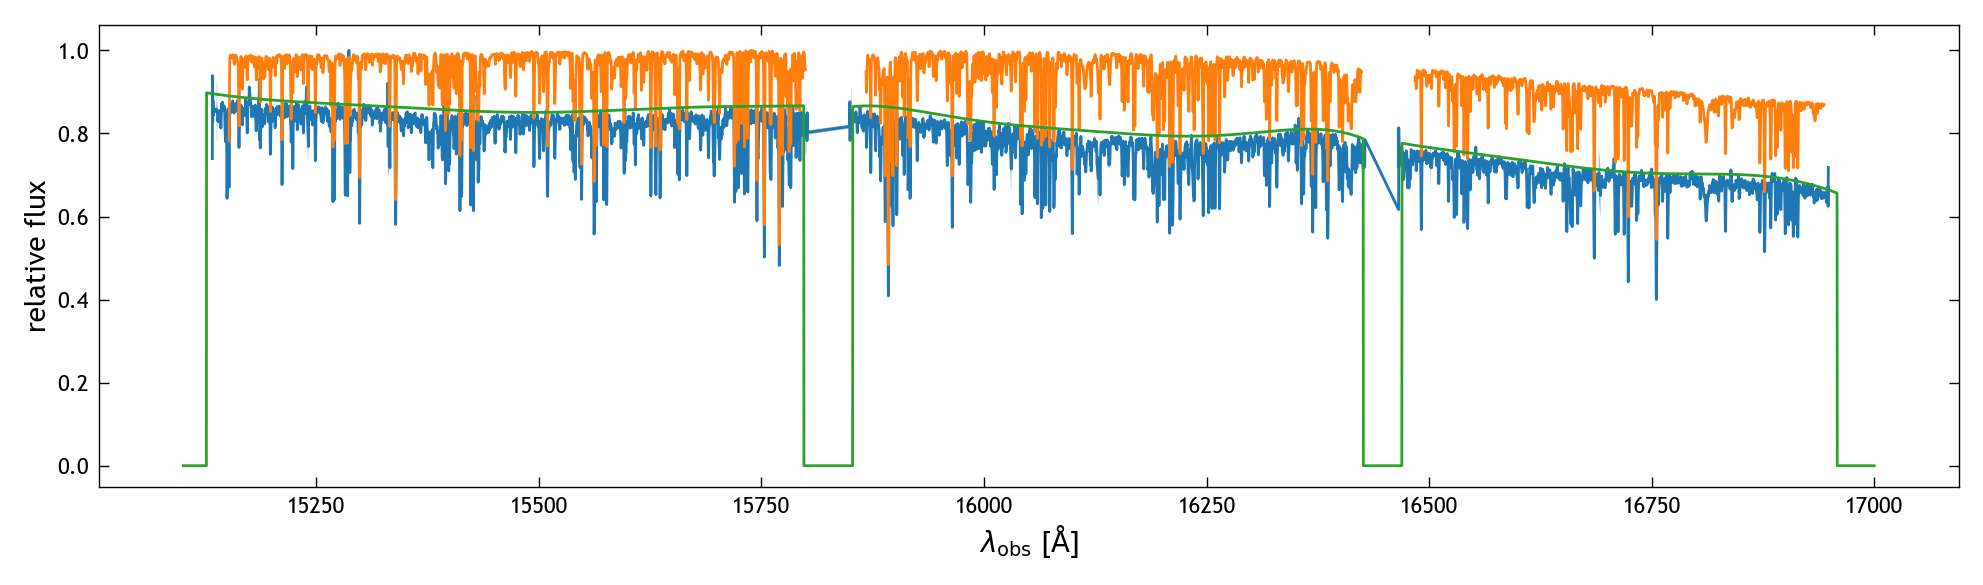

In [19]:
fig, ax = plt.subplots(figsize=(12, 3))
mask = obs_err < 0.1 * obs_flux
maxflux = obs_flux[mask].max()
ax.plot(obs_wl[mask], obs_flux[mask]/maxflux)
ax.fill_between(
    obs_wl[mask], 
    (obs_flux[mask] - obs_err[mask])/maxflux, 
    (obs_flux[mask] + obs_err[mask])/maxflux, 
    alpha=0.5
)
ax.plot(model_wl, model_flux/model_flux.max())
ax.plot(obs_wl, obs_cont/maxflux)
ax.set_xlabel(r'$\lambda_{\rm obs}$ [${\rm \AA}$]')
ax.set_ylabel('relative flux')
plt.show()

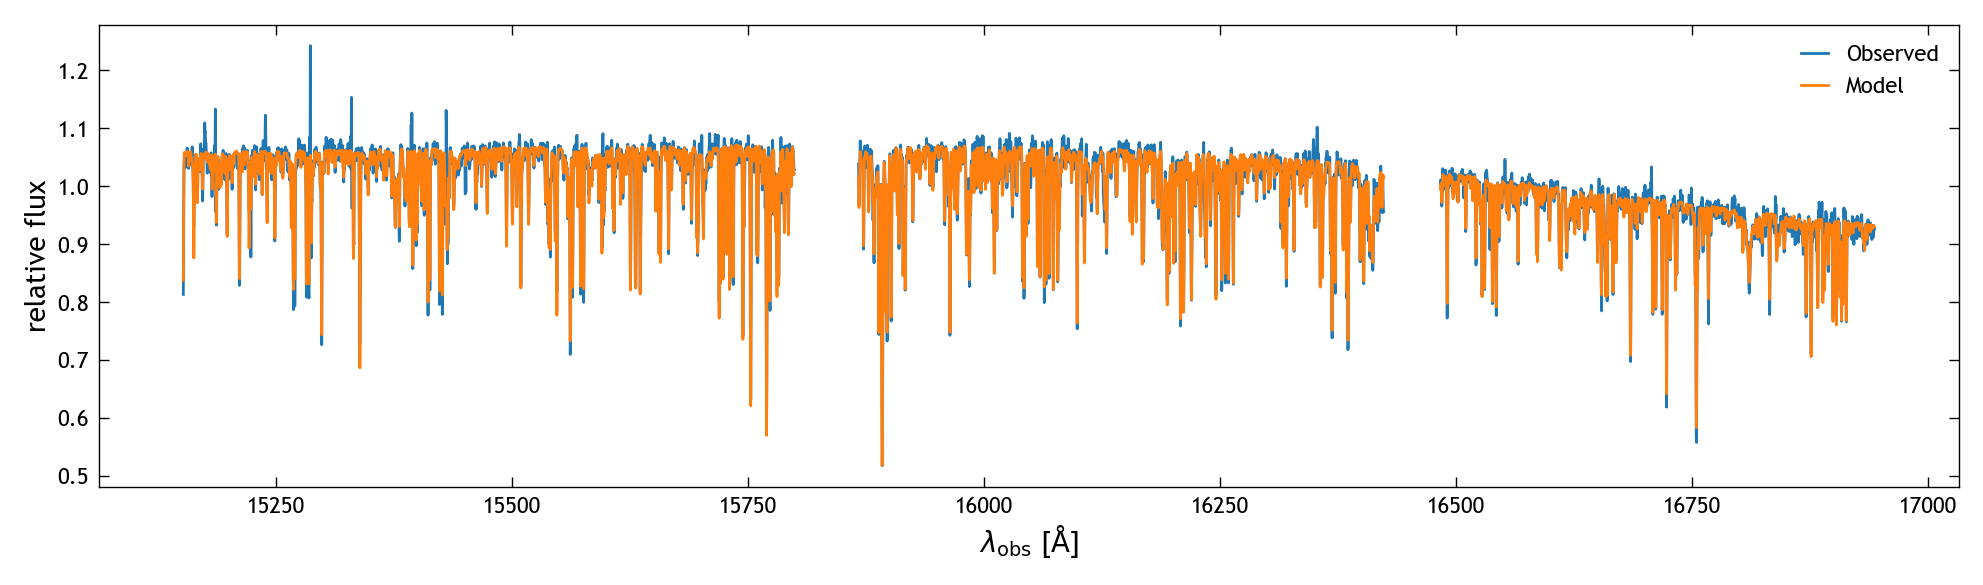

In [20]:
fig, ax = plt.subplots(figsize=(12, 3))
mask = obs_err < 0.1 * obs_flux
maxflux = obs_flux[mask].max()
ax.plot(obs_wl[mask], obs_flux[mask]/model_cont[mask], label='Observed')
ax.plot(model_wl, model_flux, label='Model')
# ax.plot(obs_wl, obs_cont/maxflux)
ax.set_xlabel(r'$\lambda_{\rm obs}$ [${\rm \AA}$]')
ax.set_ylabel('relative flux')
ax.legend()
plt.show()

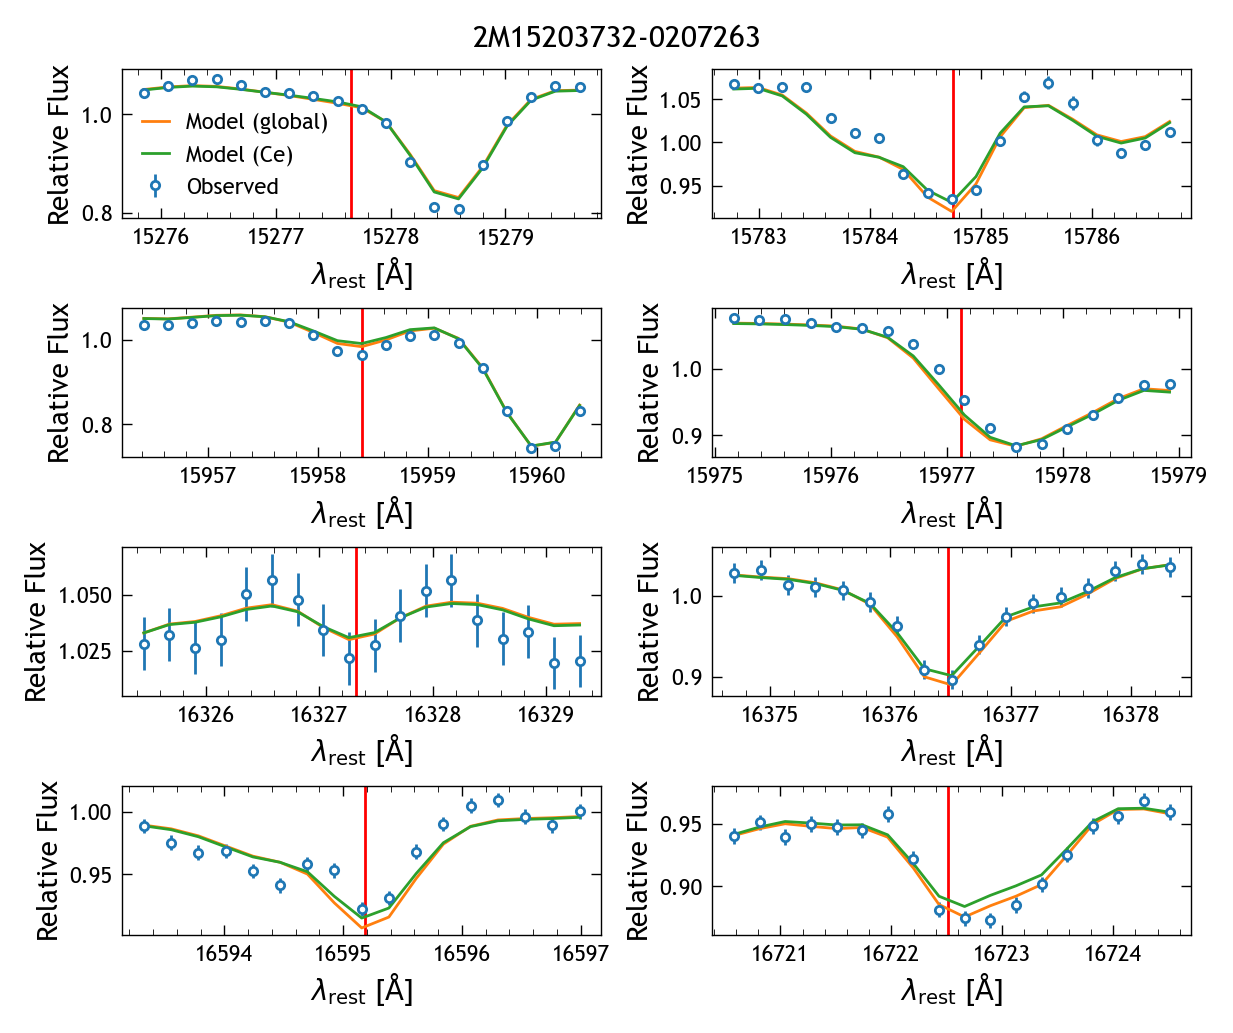

In [21]:
# Individual lines
ce_ii_lines = [15277.65, 15784.75, 15958.40, 15977.12, 16327.32, 16376.48, 16595.18, 16722.51] # Angstroms, from Cunha+ (2017)

fig, axs = plt.subplots(4, 2, figsize=(6, 5), constrained_layout=True)
for i, ax in enumerate(axs.flatten()):
    line = ce_ii_lines[i]
    ax.axvline(line, color='r')
    wl_range = (line-2, line+2)
    mask = (air_wl >= wl_range[0]) & (air_wl < wl_range[1])
    ax.errorbar(
        air_wl[mask], obs_flux[mask]/model_cont[mask], 
        yerr=obs_err[mask]/model_cont[mask], 
        fmt='o', ms=3, mfc='w', capsize=0,
        label='Observed'
    )
    ax.plot(air_wl[mask], model_flux[mask], label='Model (global)')
    ax.plot(air_wl[mask], model_ce_flux[mask], label='Model (Ce)')
    ax.set_xlabel(r'$\lambda_{\rm rest}$ [${\rm \AA}$]')
    ax.set_ylabel('Relative Flux')
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.xaxis.set_minor_locator(MultipleLocator(0.2))
    ax.ticklabel_format(style='plain', axis='x', useOffset=False)
axs[0,0].legend()
fig.suptitle(mwmStar['obj'][0])
plt.show()

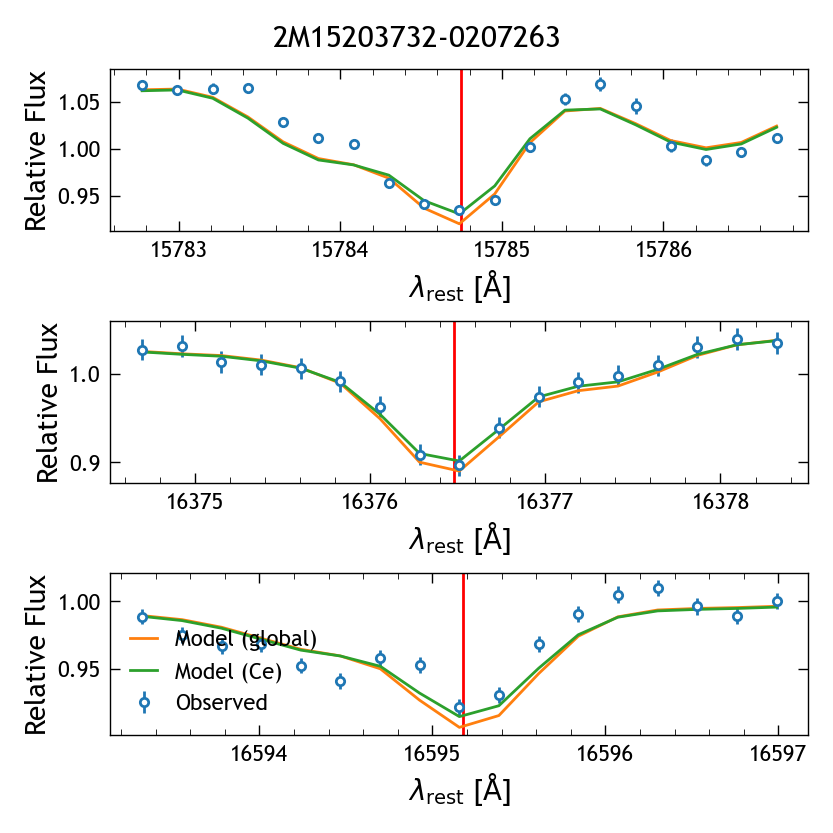

In [22]:
# Individual lines
# Comparison with Cunha+ (2017) Figure 6, for 2M15203732-0207263
ce_ii_lines = [15784.75, 16376.48, 16595.18] # Angstroms

fig, axs = plt.subplots(3, figsize=(4, 4), constrained_layout=True)
for i, ax in enumerate(axs):
    line = ce_ii_lines[i]
    ax.axvline(line, color='r')
    # ax.axvline(line+3.8, color='r', linestyle='--')
    wl_range = (line-2, line+2)
    mask = (air_wl >= wl_range[0]) & (air_wl < wl_range[1])
    ax.errorbar(
        air_wl[mask], obs_flux[mask]/model_cont[mask], 
        yerr=obs_err[mask]/model_cont[mask], 
        fmt='o', ms=3, mfc='w', capsize=0,
        label='Observed'
    )
    ax.plot(air_wl[mask], model_flux[mask], label='Model (global)')
    ax.plot(air_wl[mask], model_ce_flux[mask], label='Model (Ce)')
    ax.set_xlabel(r'$\lambda_{\rm rest}$ [${\rm \AA}$]')
    ax.set_ylabel('Relative Flux')
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.xaxis.set_minor_locator(MultipleLocator(0.2))
    ax.ticklabel_format(style='plain', axis='x', useOffset=False)
axs[-1].legend(loc='lower left')
fig.suptitle(mwmStar['obj'][0])
plt.show()

### Ce windows

In [ ]:
def get_apogee_segment_indices():
    segment_log10_wl_start = np.array([4.180476e+00, 4.20051e+00, 4.217064e+00])
    segment_pixels = np.array([3028, 2495, 1991])
    start_indices = np.round((segment_log10_wl_start - 4.179) / 6e-6).astype(int)
    return (start_indices, segment_pixels)

def get_ferre_pixel_mask():
    mask = np.zeros(8575, dtype=bool)
    for si, p in zip(*get_apogee_segment_indices()):
        mask[si:si+p] = True
    assert mask.sum() == 7514
    return mask

ferre_ce_mask = np.loadtxt("/uufs/chpc.utah.edu/common/home/sdss51/sdsswork/mwm/spectro/astra/component_data/aspcap/masks_ipl3/Ce.mask")

ferre_mask = get_ferre_pixel_mask()

ce_mask = np.zeros(ferre_mask.size, dtype=bool)
ce_mask[ferre_mask] = ferre_ce_mask

NameError: name 'np' is not defined

## Comparing spectra with similar Ce, Fe at different log(g)

In [289]:
solar_abund = mwm_sample[
    (mwm_sample['fe_h'] >= -0.22) &
    (mwm_sample['fe_h'] < -0.18) &
    (mwm_sample['mg_fe'] >= -0.05) &
    (mwm_sample['mg_fe'] < 0.05) &
    (mwm_sample['ce_fe'] >= 0.25) &
    (mwm_sample['ce_fe'] < 0.35)
]
solar_abund.sort_values('snr', inplace=True)
solar_abund

,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,catalogid25,...,Rg,orbit_flags,fe_h_corr,ce_h_corr,fe_mg_corr,mg_fe_corr,ce_mg_corr,ce_fe_corr,low_alpha,high_alpha
sdss_id,,,,,,,,,,,,,,,,,,,,,
68266056,NaN,2174461166528432256,2174461166528432256,430072680,18585,tic_v8,25,27021597803133994,4243675075,27021597803133994,...,10.495981,0.0,-0.183092,0.085383,0.013884,-0.013884,0.282360,0.268475,True,False
55007442,2M05001854+6425003,479355085095646720,479355085095646720,66659296,9441,gaia_dr3_source,31,63050394799172582,4329933172,27021597889078373,...,12.025003,0.0,-0.181856,0.141821,-0.008506,0.008506,0.315171,0.323677,True,False
54492827,NaN,429866616490563584,429866616490563584,406900801,11401,tic_v8,25,27021597853787379,4294513179,27021597853787379,...,11.290229,0.0,-0.213295,0.067946,0.012204,-0.012204,0.293444,0.281240,True,False
55104758,2M03430995+6838558,493566204162138752,493566204162138752,276188401,6880,gaia_dr3_source,31,63050394801253163,4327517937,27021597886675875,...,10.046211,0.0,-0.188212,0.179425,0.005253,-0.005253,0.372891,0.367637,True,False
68449137,2M21072282+5602029,2189317183522247808,2189317183522247808,344012918,16700,gaia_dr3_source,31,63050395042649526,4269527959,27021597828904887,...,10.393005,0.0,-0.193719,0.131289,-0.008617,0.008617,0.316392,0.325009,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115505797,2M04163442+2802386,164477288725579392,164477288725579392,58174794,52059,gaia_dr3_source,31,63050396558096356,4508817179,27021598066533724,...,10.476843,0.0,-0.183962,0.139488,0.021215,-0.021215,0.344665,0.323450,True,False
69027886,NaN,2259633288574028800,2259633288574028800,229700648,5890,tic_v8,25,27021599489199461,4284451288,27021599489199461,...,9.276081,0.0,-0.210379,0.074274,-0.006133,0.006133,0.278520,0.284653,True,False
57450771,2M07390891+2203222,865454292604141824,865454292604141824,70462448,61347,gaia_dr3_source,31,63050394824636985,4543229857,27021599488352760,...,10.956695,0.0,-0.215212,0.102979,0.003841,-0.003841,0.322031,0.318190,True,False


In [305]:
solar_abund_high_snr_ids = []
solar_abund_low_snr_ids = []
logg_bins = [1, 1.5, 2, 2.5, 3, 3.5]
for i in range(len(logg_bins)-1):
    solar_abund_logg = solar_abund[
        (solar_abund['logg'] >= logg_bins[i]) &
        (solar_abund['logg'] < logg_bins[i+1])
    ]
    print(solar_abund_logg[['logg', 'teff', 'snr', 'ce_fe', 'fe_h', 'apred']])
    solar_abund_low_snr_ids.append(solar_abund_logg.index[0])
    solar_abund_high_snr_ids.append(solar_abund_logg.index[-1])

print(solar_abund_low_snr_ids)
print(solar_abund_high_snr_ids)

               logg       teff         snr     ce_fe      fe_h apred
sdss_id                                                             
98701415   1.409557  4153.1910  102.825350  0.251348 -0.194071  dr17
116498585  1.461736  4124.4185  106.089775  0.258361 -0.219631   1.3
68572208   1.329759  4062.2910  108.426670  0.331824 -0.208951   1.3
116442773  1.315870  4011.3313  111.325640  0.283608 -0.199151   1.3
54530815   1.257450  4042.7527  113.547710  0.333424 -0.201801   1.3
...             ...        ...         ...       ...       ...   ...
76423170   1.360133  4032.0537  806.645140  0.320408 -0.200061  dr17
77128151   1.256134  4039.3574  822.383800  0.340752 -0.216031  dr17
77537770   1.284431  4035.9917  829.703000  0.304431 -0.214831  dr17
116068993  1.491834  4103.5640  912.860350  0.335549 -0.190511  dr17
77375887   1.408387  4052.1620  929.423460  0.315849 -0.211881  dr17

[101 rows x 6 columns]
               logg       teff          snr     ce_fe      fe_h apred
sdss_id  

In [284]:
mwm_sample.loc[solar_abund_high_snr_ids].telescope

sdss_id
96158235    lco25m
54997325    apo25m
55780320    apo25m
60439822    apo25m
74351741    apo25m
Name: telescope, dtype: str

In [285]:
# Download data
access.reset()
access.remote()
for sdss_id in solar_abund_high_snr_ids:
    access.add('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)
    access.add('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=sdss_id)
access.set_stream()
access.commit()

Progress:  20%|██        | 2/10 [00:05<00:20,  2.50s/files, n_files=10, n_streams=5]

SDSS_ACCESS> Done!


In [286]:
# Extract spectra
mwmStar_list = []
aspcap_list = []
for sdss_id in solar_abund_high_snr_ids:
    mwmStar_filename = access.full('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)
    aspcap_filename = access.full('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=sdss_id)
    # Determine telescope / hdu entry
    if mwm_sample.loc[sdss_id].telescope == 'apo25m':
        hdu = 3
    else:
        hdu = 4
    # Read fits file
    mwmStar = Table.read(mwmStar_filename, hdu=hdu)
    mwmStar_list.append(mwmStar)
    aspcap = Table.read(aspcap_filename, hdu=hdu)
    aspcap_list.append(aspcap)

[WARNING]: /var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_77584/1007115272.py:12: RuntimeWarning: divide by zero encountered in power
  flux_err = mwmStar['ivar'][0]**-0.5 / aspcap['continuum'][0]



0.011371811
0.014985041
0.017033031
0.016220845
0.003128757
0.0027170957
0.013812924
0.011898447


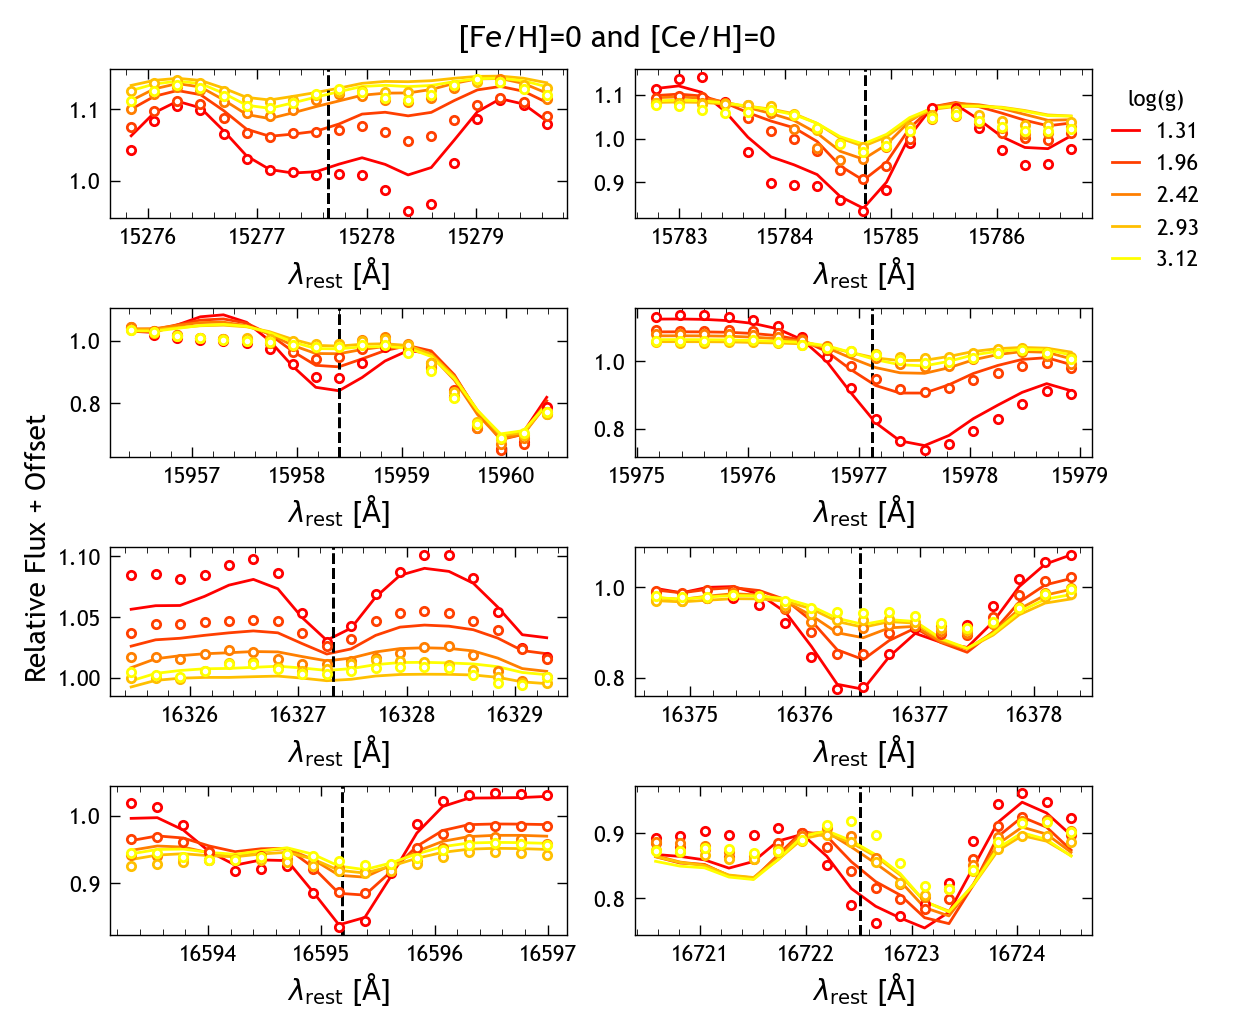

In [287]:
ce_ii_lines = [15277.65, 15784.75, 15958.40, 15977.12, 16327.32, 16376.48, 16595.18, 16722.51] # Angstroms, from Cunha+ (2017)

fig, axs = plt.subplots(4, 2, figsize=(6, 5), constrained_layout=True)
offsets = [-0.2, -0.1, 0, 0.1, 0.2]
cmap = plt.get_cmap('autumn')
norm = BoundaryNorm(logg_bins, cmap.N)
for j, sdss_id in enumerate(solar_abund_high_snr_ids):
    mwmStar = mwmStar_list[j]
    aspcap = aspcap_list[j]
    wl_arr = vac2air(mwmStar['wavelength'][0])
    flux = mwmStar['flux'][0] / aspcap['continuum'][0]
    flux_err = mwmStar['ivar'][0]**-0.5 / aspcap['continuum'][0]
    weights = mwmStar['ivar'][0]
    model = aspcap['model_flux_ce_h'][0]
    logg = mwm_sample.loc[sdss_id]['logg']
    offset = j*0.02
    for i, ax in enumerate(axs.flatten()):
        line = ce_ii_lines[i]
        ax.axvline(line, color='k', linestyle='--')
        wl_range = (line-2, line+2)
        mask = (wl_arr >= wl_range[0]) & (wl_arr < wl_range[1])
        if j==4: print(np.median(weights[mask]))
        # ax.plot(wl_arr[mask], flux[mask]/flux[mask].max(), label=round(logg, 2))
        # ax.fill_between(
        #     wl_arr[mask],
        #     (flux[mask] - flux_err[mask]) / flux[mask].max(),
        #     (flux[mask] + flux_err[mask]) / flux[mask].max(),
        #     alpha=0.5
        # )
        ax.errorbar(
            wl_arr[mask], flux[mask], 
            yerr=flux_err[mask], 
            fmt='o', ms=3, mfc='w', capsize=0,
            color=cmap(norm(logg))
            # label=round(logg, 2)
        )
        ax.plot(wl_arr[mask], model[mask], c=cmap(norm(logg)), label=round(logg, 2))
        ax.set_xlabel(r'$\lambda_{\rm rest}$ [${\rm \AA}$]')
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.xaxis.set_minor_locator(MultipleLocator(0.2))
        ax.ticklabel_format(style='plain', axis='x', useOffset=False)
axs[2,0].set_ylabel('Relative Flux + Offset', y=1)
axs[0,1].legend(title='log(g)', bbox_to_anchor=(1,1), loc='upper left')
fig.suptitle('[Fe/H]=0 and [Ce/H]=0')
plt.show()

## Same log(g) and [Fe/H], different [Ce/H]

### Upper RGB

In [302]:
same_logg_feh = mwm_sample[
    (mwm_sample['fe_h'] >= -0.55) &
    (mwm_sample['fe_h'] < -0.45) &
    # (mwm_sample['mg_fe'] >= 0) &
    # (mwm_sample['mg_fe'] < 0.1) &
    (mwm_sample['logg'] >= 1.9) &
    (mwm_sample['logg'] < 2.1)
]
same_logg_feh.sort_values('snr', inplace=True)
same_logg_feh

,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,catalogid25,...,Rg,orbit_flags,fe_h_corr,ce_h_corr,fe_mg_corr,mg_fe_corr,ce_mg_corr,ce_fe_corr,low_alpha,high_alpha
sdss_id,,,,,,,,,,,,,,,,,,,,,
83891502,2M19100795-1723555,4087866554281772160,4087866554281772160,446472074,127641,gaia_dr3_source,31,63050395374828011,5070132767,27021598626804799,...,2.043503,0.0,-0.494088,-0.430664,-0.275566,0.275566,-0.212142,0.063424,False,True
81070975,2M18072974-3729042,4037782420940110336,4037782420940110336,330034717,158339,gaia_dr3_source,31,63050395186975240,4893237460,27021598450005446,...,0.770676,0.0,-0.537449,-0.526796,-0.261437,0.261437,-0.250784,0.010653,False,True
77744740,2M05452684+3000203,3444351226348093184,3444351226348093184,117007182,49018,gaia_dr3_source,31,63050395155064262,4512560837,27021598070263594,...,14.818485,0.0,-0.520109,-0.417298,-0.057334,0.057334,0.045477,0.102811,True,False
115699781,2M05151717+3947550,188707359612406400,188707359612406400,238935106,35184,gaia_dr3_source,31,63050396562102200,4518770565,27021598076454373,...,17.120014,0.0,-0.465528,-0.409980,-0.086579,0.086579,-0.031030,0.055548,True,False
89571168,NaN,4491920550439544192,4491920550439544192,302429477,80501,tic_v8,25,27021598736662528,5180117368,27021598736662528,...,5.184343,0.0,-0.485463,-0.388801,-0.056979,0.056979,0.039683,0.096662,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71908751,NaN,2840910760800508544,2840910760800508544,28394904,57075,tic_v8,21,4384445565,4384445565,27021599488572666,...,8.631256,0.0,-0.517370,-0.287013,-0.073530,0.073530,0.156827,0.230357,True,False
57578379,NaN,878879608754264960,878879608754264960,423089442,49574,tic_v8,21,4554576297,4554576297,27021599488482024,...,11.030253,0.0,-0.477156,-0.396363,-0.058119,0.058119,0.022674,0.080793,True,False
70129109,2M02323266+0122184,2502884396379062400,2502884396379062400,422899343,95542,gaia_dr3_source,31,63050395066178782,4401863209,27021599488058738,...,10.028358,0.0,-0.467502,-0.390587,-0.253910,0.253910,-0.176995,0.076915,False,True


In [303]:
cefe_bins = np.arange(-0.5, 0.51, 0.2)
for i in range(len(cefe_bins)-1):
    same_logg_cefe = same_logg_feh[
        (same_logg_feh['ce_fe'] >= cefe_bins[i]) &
        (same_logg_feh['ce_fe'] < cefe_bins[i+1])
    ]
    print(same_logg_cefe[['fe_h', 'ce_fe', 'snr']])

              fe_h     ce_fe        snr
sdss_id                                
60028811 -0.504521 -0.431659  101.05100
88786473 -0.477421 -0.326169  105.33550
62567014 -0.501141 -0.404239  113.13266
61189798 -0.455471 -0.345859  154.02408
61193173 -0.534371 -0.342409  164.30930
62793899 -0.491981 -0.312209  174.08127
54760914 -0.499801 -0.311419  223.99810
79569198 -0.485181 -0.307339  291.50043
60327513 -0.509901 -0.300649  294.50568
75933928 -0.507881 -0.348099  386.10214
               fe_h     ce_fe          snr
sdss_id                                   
85111897  -0.492841 -0.114409   100.950775
55081702  -0.535011 -0.170399   101.208600
107082603 -0.467311 -0.123039   101.361595
88973332  -0.490141 -0.149509   101.485070
85119940  -0.510451 -0.264449   104.062614
...             ...       ...          ...
67969288  -0.507091 -0.165089   646.176000
88915240  -0.490771 -0.138849   702.001460
113662230 -0.508891 -0.127489   726.379300
62061890  -0.530971 -0.120589   805.449340
7915

In [154]:
same_logg_high_snr_ids = []
cefe_bins = np.arange(-0.5, 0.51, 0.2)
for i in range(len(cefe_bins)-1):
    same_logg_cefe = same_logg_feh[
        (same_logg_feh['ce_fe'] >= cefe_bins[i]) &
        (same_logg_feh['ce_fe'] < cefe_bins[i+1])
    ]
    same_logg_high_snr_ids.append(same_logg_cefe.index[-1])

print(same_logg_high_snr_ids)

[np.int64(75933928), np.int64(113662230), np.int64(74363275), np.int64(71908751), np.int64(115549731)]


In [156]:
# Download data
access.reset()
access.remote()
for sdss_id in same_logg_high_snr_ids:
    print(sdss_id)
    access.add('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)
    access.add('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=sdss_id)
access.set_stream()
access.commit()

75933928
113662230
74363275
71908751
115549731


Progress:  20%|██        | 2/10 [00:05<00:20,  2.50s/files, n_files=10, n_streams=5]

SDSS_ACCESS> Done!


In [160]:
# Extract spectra
mwmStar_list = []
aspcap_list = []
for sdss_id in same_logg_high_snr_ids:
    mwmStar_filename = access.full('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)
    aspcap_filename = access.full('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=sdss_id)
    # Determine telescope / hdu entry
    if mwm_sample.loc[sdss_id].telescope == 'apo25m':
        hdu = 3
    else:
        hdu = 4
    # Read fits file
    mwmStar = Table.read(mwmStar_filename, hdu=hdu)
    mwmStar_list.append(mwmStar)
    aspcap = Table.read(aspcap_filename, hdu=hdu)
    aspcap_list.append(aspcap)

[WARNING]: /var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_77584/1169363198.py:12: RuntimeWarning: divide by zero encountered in power
  flux_err = mwmStar['ivar'][0]**-0.5 / aspcap['continuum'][0]



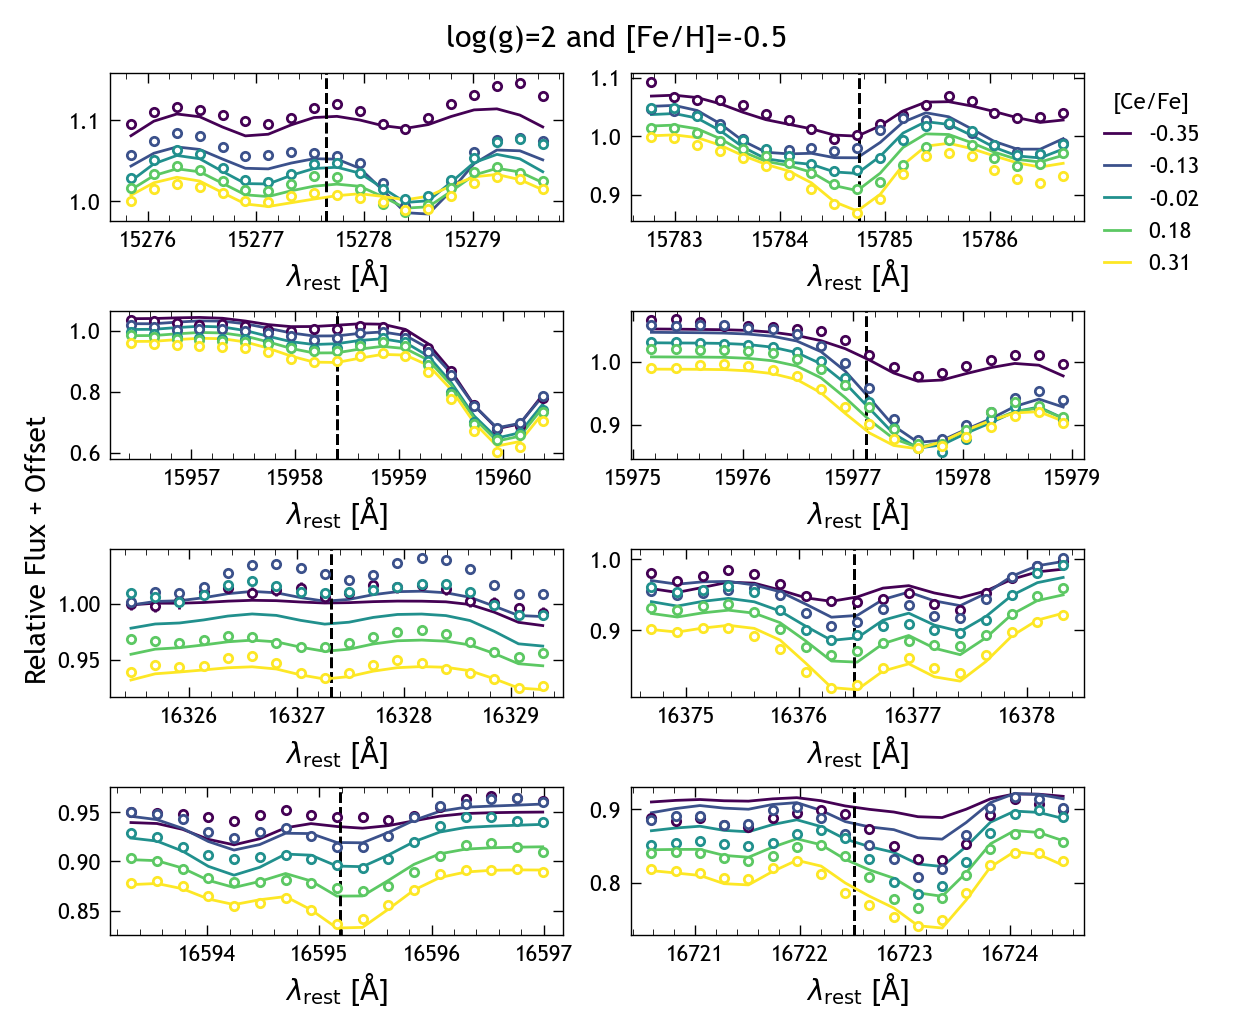

In [161]:
ce_ii_lines = [15277.65, 15784.75, 15958.40, 15977.12, 16327.32, 16376.48, 16595.18, 16722.51] # Angstroms, from Cunha+ (2017)

fig, axs = plt.subplots(4, 2, figsize=(6, 5), constrained_layout=True)
cmap = plt.get_cmap('viridis')
norm = BoundaryNorm(cefe_bins, cmap.N)
for j, sdss_id in enumerate(same_logg_high_snr_ids):
    mwmStar = mwmStar_list[j]
    aspcap = aspcap_list[j]
    # print(aspcap['ce_h'])
    wl_arr = vac2air(mwmStar['wavelength'][0])
    flux = mwmStar['flux'][0] / aspcap['continuum'][0]
    flux_err = mwmStar['ivar'][0]**-0.5 / aspcap['continuum'][0]
    model = aspcap['model_flux_ce_h'][0]
    cefe = mwm_sample.loc[sdss_id]['ce_fe']
    offset = j*-0.02
    for i, ax in enumerate(axs.flatten()):
        line = ce_ii_lines[i]
        ax.axvline(line, color='k', linestyle='--')
        wl_range = (line-2, line+2)
        mask = (wl_arr >= wl_range[0]) & (wl_arr < wl_range[1])
        # if i == 0: 
        #     print(aspcap['continuum'][0][mask])
        #     print(aspcap['model_flux'][0][mask])
        #     print(aspcap['model_flux_fe_h'][0][mask])
        ax.errorbar(
            wl_arr[mask], flux[mask]+offset, 
            yerr=flux_err[mask], 
            fmt='o', ms=3, mfc='w', capsize=0,
            color=cmap(norm(cefe))
        )
        ax.plot(
            wl_arr[mask], model[mask]+offset, 
            c=cmap(norm(cefe)), 
            label=round(cefe, 2)
        )
        ax.set_xlabel(r'$\lambda_{\rm rest}$ [${\rm \AA}$]')
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.xaxis.set_minor_locator(MultipleLocator(0.2))
        ax.ticklabel_format(style='plain', axis='x', useOffset=False)
axs[2,0].set_ylabel('Relative Flux + Offset', y=1)
fig.suptitle('log(g)=2 and [Fe/H]=-0.5')
axs[0,1].legend(title='[Ce/Fe]', bbox_to_anchor=(1,1), loc='upper left')
plt.show()

### Lower RGB

In [293]:
same_logg_feh = mwm_sample[
    (mwm_sample['fe_h'] >= -0.55) &
    (mwm_sample['fe_h'] < -0.45) &
    # (mwm_sample['mg_fe'] >= 0.0) &
    # (mwm_sample['mg_fe'] < 0.1) &
    (mwm_sample['logg'] >= 2.9) &
    (mwm_sample['logg'] < 3.1)
]
same_logg_feh.sort_values('snr', inplace=True)
same_logg_feh

,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,catalogid25,...,Rg,orbit_flags,fe_h_corr,ce_h_corr,fe_mg_corr,mg_fe_corr,ce_mg_corr,ce_fe_corr,low_alpha,high_alpha
sdss_id,,,,,,,,,,,,,,,,,,,,,
57881640,2M08202635+4106246,915463384266048768,915463384266048768,18784128,33202,gaia_dr3_source,31,63050394827475870,4361387693,27021597920199209,...,8.426520,0.0,-0.512581,-0.459110,-0.329148,0.329148,-0.275678,0.053470,False,True
61615330,2M14235974+3919099,1490780541397675648,1490780541397675648,27435199,35891,gaia_dr3_source,31,63050394849909979,4350818791,27021597909813966,...,7.588838,0.0,-0.482105,-0.583642,-0.184433,0.184433,-0.285969,-0.101537,False,True
116034431,2M03561906+3750026,220569561612016896,220569561612016896,187085321,38228,gaia_dr3_source,31,63050396569228927,4508344328,27021598066063311,...,9.604939,0.0,-0.501266,-0.530890,-0.089123,0.089123,-0.118748,-0.029624,True,False
62367434,NaN,1630805202620946048,1630805202620946048,287151862,11012,tic_v8,25,27021597906391754,4347333749,27021597906391754,...,7.419715,0.0,-0.455488,-0.523365,-0.100526,0.100526,-0.168402,-0.067876,True,False
60861108,NaN,1367533396822708992,1367533396822708992,356237917,22152,tic_v8,25,27021597903651194,4344553057,27021597903651194,...,6.720555,0.0,-0.496974,0.127868,-0.270031,0.270031,0.354811,0.624842,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79977101,NaN,3839155752749549952,3839155752749549952,277439086,99783,tic_v8,25,27021599489306774,4570500507,27021599489306774,...,8.869854,0.0,-0.529035,-0.506896,-0.109399,0.109399,-0.087260,0.022139,True,False
59422194,2M14571134+0112177,1153308536995622400,1153308536995622400,-1,95807,gaia_dr3_source,31,63050394838652872,7463243939,27021602286950306,...,9.245691,0.0,-0.453060,-0.480113,-0.231377,0.231377,-0.258430,-0.027053,False,True
61854612,2M12083745+4038459,1536129241354080640,1536129241354080640,21598088,34307,gaia_dr3_source,31,63050394850726038,4602572311,27021599488783672,...,7.865763,0.0,-0.448473,-0.391556,-0.058989,0.058989,-0.002073,0.056916,True,False


In [294]:
same_logg_high_snr_ids = []
cefe_bins = [(-1.1, -0.9), (-0.6, -0.4), (-0.3, -0.1), (-0.1, 0.1), (0.1, 0.3), (0.4, 0.6), (0.9, 1.1)]
for i in range(len(cefe_bins)-1):
    same_logg_cefe = same_logg_feh[
        (same_logg_feh['ce_fe'] >= cefe_bins[i][0]) &
        (same_logg_feh['ce_fe'] < cefe_bins[i][1])
    ]
    print(same_logg_cefe[['fe_h', 'ce_fe', 'snr']])
    same_logg_high_snr_ids.append(same_logg_cefe.index[-1])

print(same_logg_high_snr_ids)

              fe_h     ce_fe        snr
sdss_id                                
76102106 -0.463461 -0.906919  167.49942
63243285 -0.497931 -0.902349  213.01256
              fe_h     ce_fe        snr
sdss_id                                
95564462 -0.536131 -0.485749  115.55626
78958278 -0.545311 -0.431169  120.90811
57551964 -0.455921 -0.427759  141.48546
59421456 -0.458441 -0.487439  144.56807
59309243 -0.496891 -0.528189  144.59880
79985469 -0.509521 -0.435059  164.71579
69228929 -0.497161 -0.545619  188.60492
80410088 -0.498141 -0.400739  203.15152
58607588 -0.492701 -0.484579  212.13919
89064761 -0.531211 -0.434569  218.31607
60480005 -0.508241 -0.491639  229.11978
60142162 -0.501351 -0.599929  250.17174
59100443 -0.468861 -0.537719  252.14480
61057592 -0.546911 -0.557569  267.46698
60453028 -0.548751 -0.566929  343.76855
62361950 -0.470941 -0.402339  383.64760
58719230 -0.469531 -0.425749  416.75528
60342741 -0.514601 -0.418279  430.48172
57592391 -0.508191 -0.427089  742.05110


In [198]:
# Download data
access.reset()
access.remote()
for sdss_id in same_logg_high_snr_ids:
    access.add('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)
    access.add('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=sdss_id)
access.set_stream()
access.commit()

Progress:  17%|█▋        | 2/12 [00:05<00:25,  2.50s/files, n_files=12, n_streams=5]

SDSS_ACCESS> Done!


In [199]:
# Extract spectra
mwmStar_list = []
aspcap_list = []
for sdss_id in same_logg_high_snr_ids:
    mwmStar_filename = access.full('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)
    aspcap_filename = access.full('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=sdss_id)
    # Determine telescope / hdu entry
    if mwm_sample.loc[sdss_id].telescope == 'apo25m':
        hdu = 3
    else:
        hdu = 4
    # Read fits file
    mwmStar = Table.read(mwmStar_filename, hdu=hdu)
    mwmStar_list.append(mwmStar)
    aspcap = Table.read(aspcap_filename, hdu=hdu)
    aspcap_list.append(aspcap)

[WARNING]: /var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_77584/1466945885.py:11: RuntimeWarning: divide by zero encountered in power
  flux_err = mwmStar['ivar'][0]**-0.5 / aspcap['continuum'][0]



213.01256
742.0511
910.62054
363.996
508.38535
318.61047


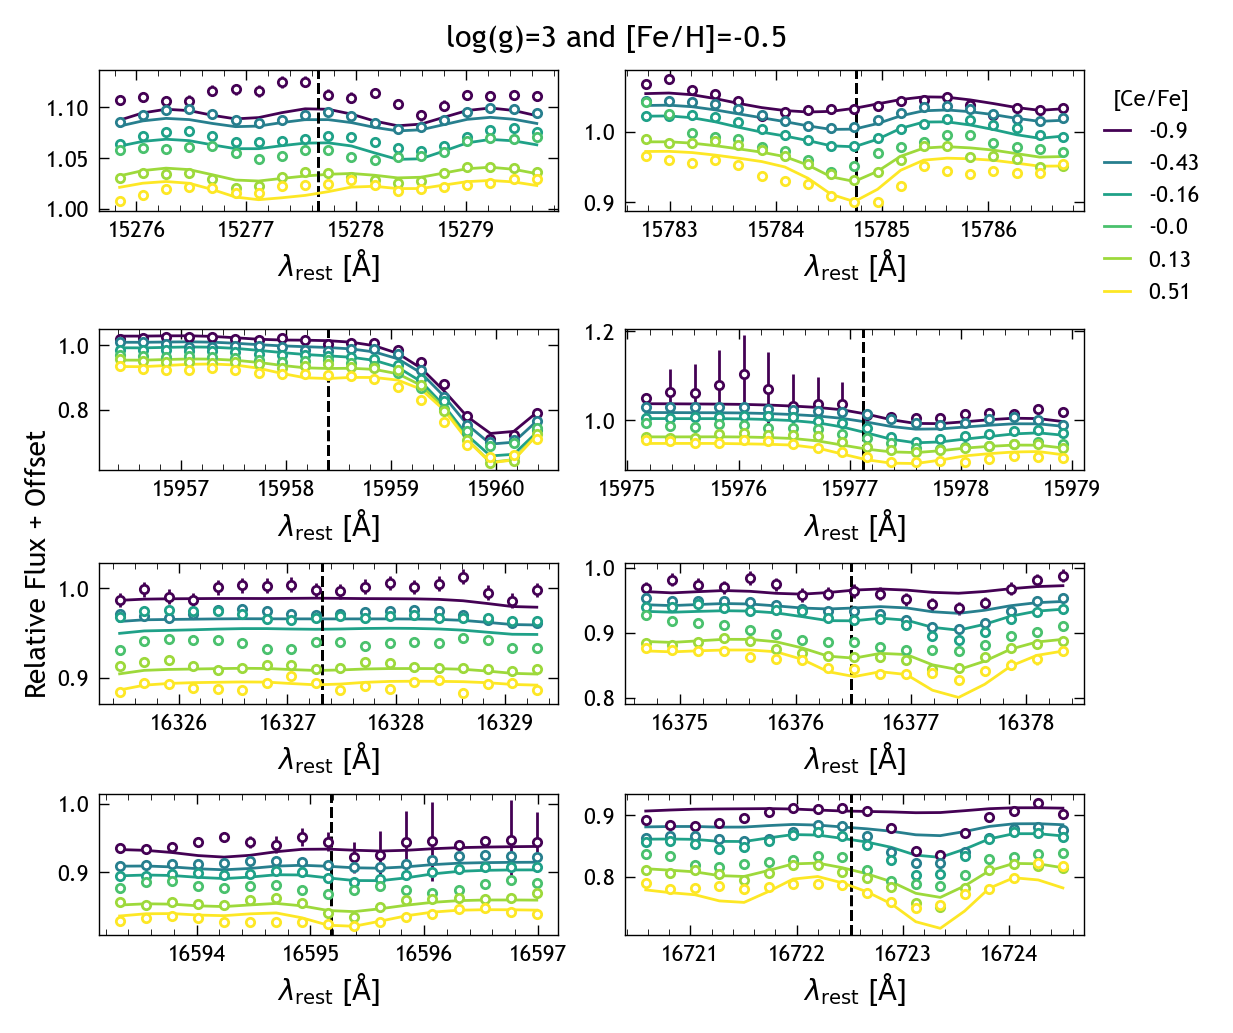

In [202]:
ce_ii_lines = [15277.65, 15784.75, 15958.40, 15977.12, 16327.32, 16376.48, 16595.18, 16722.51] # Angstroms, from Cunha+ (2017)

fig, axs = plt.subplots(4, 2, figsize=(6, 5), constrained_layout=True)
cmap = plt.get_cmap('viridis')
norm = BoundaryNorm(np.arange(-1.1, 0.51, 0.2), cmap.N)
for j, sdss_id in enumerate(same_logg_high_snr_ids):
    mwmStar = mwmStar_list[j]
    aspcap = aspcap_list[j]
    wl_arr = vac2air(mwmStar['wavelength'][0])
    flux = mwmStar['flux'][0] / aspcap['continuum'][0]
    flux_err = mwmStar['ivar'][0]**-0.5 / aspcap['continuum'][0]
    flux_err = np.where(flux_err>1, np.nan, flux_err)
    model = aspcap['model_flux_ce_h'][0]
    cefe = mwm_sample.loc[sdss_id]['ce_fe']
    offset = j*-0.02
    print(mwmStar['snr'][0])
    for i, ax in enumerate(axs.flatten()):
        line = ce_ii_lines[i]
        ax.axvline(line, color='k', linestyle='--')
        wl_range = (line-2, line+2)
        mask = (wl_arr >= wl_range[0]) & (wl_arr < wl_range[1])
        ax.errorbar(
            wl_arr[mask], flux[mask]+offset, 
            yerr=flux_err[mask], 
            fmt='o', ms=3, mfc='w', capsize=0,
            color=cmap(norm(cefe))
        )
        ax.plot(
            wl_arr[mask], model[mask]+offset, 
            c=cmap(norm(cefe)), 
            label=round(cefe, 2)
        )
        ax.set_xlabel(r'$\lambda_{\rm rest}$ [${\rm \AA}$]')
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.xaxis.set_minor_locator(MultipleLocator(0.2))
        ax.ticklabel_format(style='plain', axis='x', useOffset=False)
axs[2,0].set_ylabel('Relative Flux + Offset', y=1)
fig.suptitle('log(g)=3 and [Fe/H]=-0.5')
axs[0,1].legend(title='[Ce/Fe]', bbox_to_anchor=(1,1), loc='upper left')
plt.show()

### Sampling potentially bad abundance space

In [36]:
same_logg_feh = mwm_sample[
    (mwm_sample['fe_h'] >= -0.55) &
    (mwm_sample['fe_h'] < -0.45) &
    (mwm_sample['ce_fe'] >= -0.7) &
    (mwm_sample['ce_fe'] < -0.2) &
    (mwm_sample['logg'] >= 2.9) &
    (mwm_sample['logg'] < 3.1) &
    (mwm_sample['apred'] == '1.3')
]
same_logg_feh.sort_values('snr', inplace=True)
same_logg_feh

,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,catalogid25,...,Rg,orbit_flags,fe_h_corr,ce_h_corr,fe_mg_corr,mg_fe_corr,ce_mg_corr,ce_fe_corr,low_alpha,high_alpha
sdss_id,,,,,,,,,,,,,,,,,,,,,
62367434,NaN,1630805202620946048,1630805202620946048,287151862,11012,tic_v8,25,27021597906391754,4347333749,27021597906391754,...,7.419715,0.0,-0.455488,-0.523365,-0.100526,0.100526,-0.168402,-0.067876,True,False
61208082,NaN,1422263095627146368,1422263095627146368,320525823,15220,tic_v8,25,27021597904237051,4345145919,27021597904237051,...,5.821632,0.0,-0.461582,-0.661461,-0.242590,0.242590,-0.442468,-0.199878,False,True
89587694,NaN,4493991441934699392,4493991441934699392,263841896,76917,tic_v8,25,27021598737110768,5180567431,27021598737110768,...,6.412919,0.0,-0.499353,-0.697522,-0.273661,0.273661,-0.471829,-0.198168,False,True
55994573,NaN,613219693763009152,613219693763009152,377065658,78291,tic_v8,25,27021598150489857,4593332231,27021598150489857,...,6.077814,0.0,-0.458980,-0.689241,-0.231598,0.231598,-0.461859,-0.230261,False,True
58763599,NaN,1038542337922377088,1038542337922377088,137672142,13411,tic_v8,25,27021599489032776,4355711846,27021599489032776,...,10.212338,0.0,-0.474812,-0.734922,-0.085729,0.085729,-0.345839,-0.260110,True,False
88784533,NaN,4397503146202459008,4397503146202459008,32490061,109135,tic_v8,25,27021598333682681,4776857303,27021598333682681,...,8.161364,0.0,-0.478185,-0.709058,-0.060815,0.060815,-0.291688,-0.230873,True,False
62204779,NaN,1601635227855382016,1601635227855382016,405582941,16255,tic_v8,25,27021597905628072,4346558108,27021597905628072,...,7.270456,0.0,-0.432113,-0.915522,-0.280691,0.280691,-0.764099,-0.483409,False,True
67911585,NaN,2151853455103600512,2151853455103600512,356892865,15227,tic_v8,25,27021597828379306,4268997592,27021597828379306,...,9.957159,0.0,-0.524120,-0.588943,-0.170347,0.170347,-0.235171,-0.064824,False,True
79925089,NaN,3829671910908632576,3829671910908632576,178835260,101334,tic_v8,25,27021598128470248,4571112804,27021598128470248,...,7.442957,0.0,-0.513629,-0.749939,-0.275587,0.275587,-0.511896,-0.236310,False,True


In [55]:
same_logg_high_snr_ids = same_logg_feh.iloc[-5:].sort_values('ce_fe').index.to_list()
same_logg_high_snr_ids

[59567040, 60453028, 57592391, 62361950, 57747705]

In [40]:
# Download data
access.reset()
access.remote()
for sdss_id in same_logg_high_snr_ids:
    access.add('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)
    access.add('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=sdss_id)
access.set_stream()
access.commit()

Progress:  20%|██        | 4/20 [00:05<00:20,  1.25s/files, n_files=20, n_streams=5]

SDSS_ACCESS> Done!


In [47]:
# Extract spectra
mwmStar_list = []
aspcap_list = []
for sdss_id in same_logg_high_snr_ids:
    mwmStar_filename = access.full('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)
    aspcap_filename = access.full('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=sdss_id)
    # Determine telescope / hdu entry
    if mwm_sample.loc[sdss_id].telescope == 'apo25m':
        hdu = 3
    else:
        hdu = 4
    # Read fits file
    mwmStar = Table.read(mwmStar_filename, hdu=hdu)
    mwmStar_list.append(mwmStar)
    aspcap = Table.read(aspcap_filename, hdu=hdu)
    aspcap_list.append(aspcap)

[WARNING]: /var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_49682/2123972750.py:11: RuntimeWarning: divide by zero encountered in power
  flux_err = mwmStar['ivar'][0]**-0.5 / aspcap['continuum'][0]



333.51752
343.76855
383.6476
742.0511
769.2747


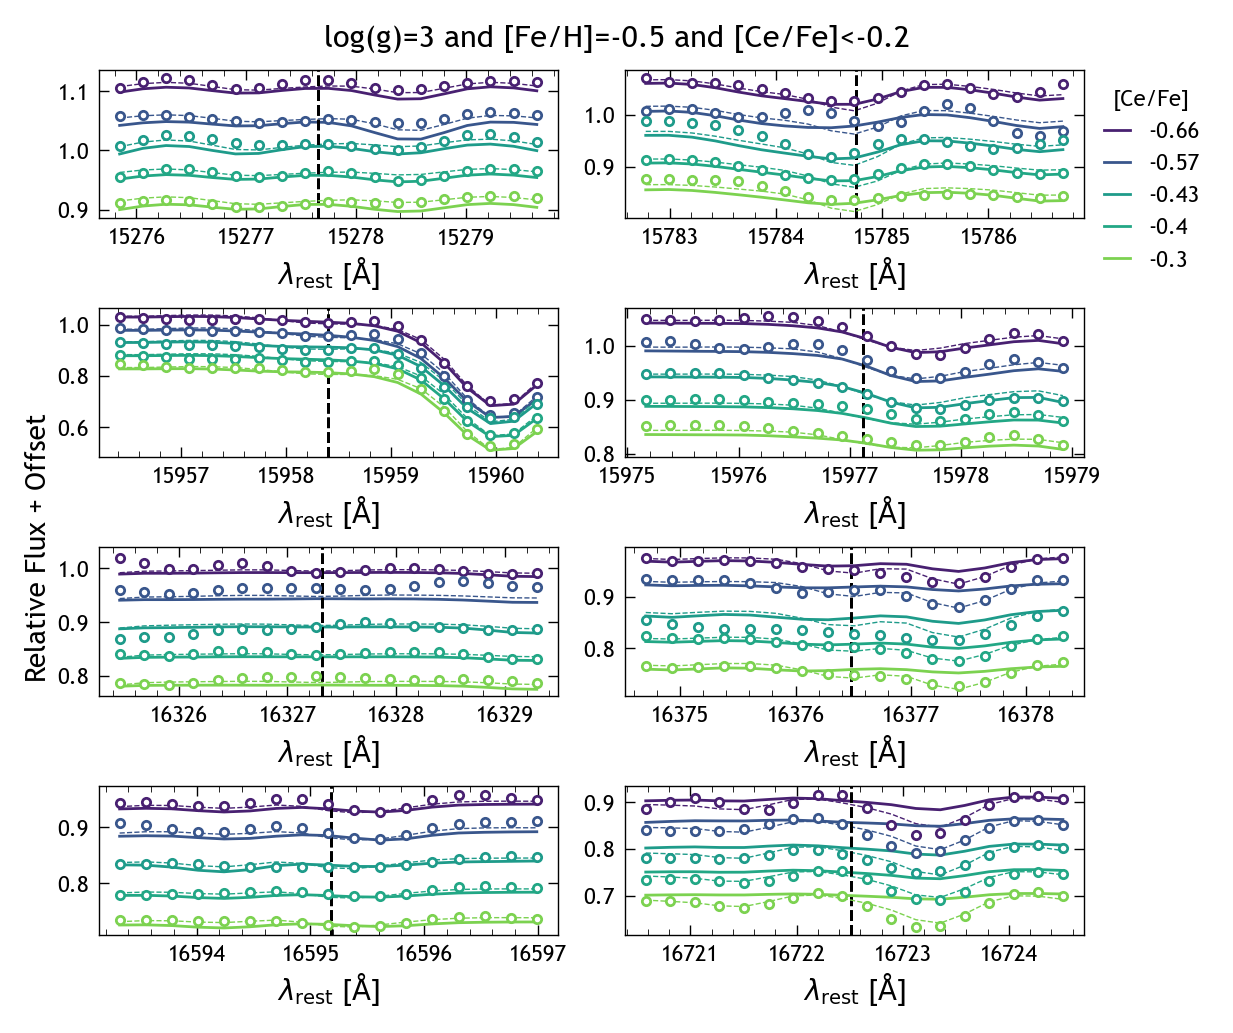

In [56]:
ce_ii_lines = [15277.65, 15784.75, 15958.40, 15977.12, 16327.32, 16376.48, 16595.18, 16722.51] # Angstroms, from Cunha+ (2017)

fig, axs = plt.subplots(4, 2, figsize=(6, 5), constrained_layout=True)
cmap = plt.get_cmap('viridis')
norm = Normalize(vmin=-0.7, vmax=-0.2)
for j, sdss_id in enumerate(same_logg_high_snr_ids):
    mwmStar = mwmStar_list[j]
    aspcap = aspcap_list[j]
    wl_arr = vac2air(mwmStar['wavelength'][0])
    flux = mwmStar['flux'][0] / aspcap['continuum'][0]
    flux_err = mwmStar['ivar'][0]**-0.5 / aspcap['continuum'][0]
    flux_err = np.where(flux_err>1, np.nan, flux_err)
    model = aspcap['model_flux_ce_h'][0]
    global_model = aspcap['model_flux'][0]
    cefe = mwm_sample.loc[sdss_id]['ce_fe']
    offset = j*-0.05
    print(mwmStar['snr'][0])
    for i, ax in enumerate(axs.flatten()):
        line = ce_ii_lines[i]
        ax.axvline(line, color='k', linestyle='--')
        wl_range = (line-2, line+2)
        mask = (wl_arr >= wl_range[0]) & (wl_arr < wl_range[1])
        ax.errorbar(
            wl_arr[mask], flux[mask]+offset, 
            yerr=flux_err[mask], 
            fmt='o', ms=3, mfc='w', capsize=0,
            color=cmap(norm(cefe))
        )
        ax.plot(
            wl_arr[mask], model[mask]+offset, 
            c=cmap(norm(cefe)), 
            label=round(cefe, 2)
        )
        ax.plot(
            wl_arr[mask], global_model[mask]+offset, 
            c=cmap(norm(cefe)), 
            ls='--', lw=0.5
        )
        ax.set_xlabel(r'$\lambda_{\rm rest}$ [${\rm \AA}$]')
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.xaxis.set_minor_locator(MultipleLocator(0.2))
        ax.ticklabel_format(style='plain', axis='x', useOffset=False)
axs[2,0].set_ylabel('Relative Flux + Offset', y=1)
fig.suptitle('log(g)=3 and [Fe/H]=-0.5 and [Ce/Fe]<-0.2')
axs[0,1].legend(title='[Ce/Fe]', bbox_to_anchor=(1,1), loc='upper left')
plt.show()

### Metal-rich, high-logg

In [24]:
same_logg_high_feh = mwm_sample[
    (mwm_sample['fe_h'] >= 0.3) &
    (mwm_sample['fe_h'] < 0.4) &
    (mwm_sample['mg_fe'] >= -0.05) &
    (mwm_sample['mg_fe'] < 0.05) &
    (mwm_sample['logg'] >= 2.9) &
    (mwm_sample['logg'] < 3.1) &
    # (mwm_sample['snr'] < 200) &
    (mwm_sample['ce_fe'] > -0.3) &
    (mwm_sample['ce_fe'] < 0.1)
]
same_logg_high_feh.sort_values('snr', inplace=True)
print(same_logg_high_feh[['fe_h', 'ce_fe', 'snr']])
same_logg_high_feh.sort_values('ce_fe', inplace=True)

               fe_h     ce_fe          snr
sdss_id                                   
109063185  0.311609 -0.208160   101.046520
106143269  0.370859 -0.017369   104.024450
106537590  0.338919  0.083121   104.578865
79793543   0.325389 -0.022889   104.622314
70982682   0.301639  0.024961   105.605310
...             ...       ...          ...
67108790   0.303079 -0.170426   433.636960
75707003   0.362459 -0.061379   524.054800
57972283   0.391259 -0.278039   564.194500
109003527  0.360819  0.007431   747.530940
56386985   0.323679  0.095951  1576.197400

[98 rows x 3 columns]


In [25]:
high_met_ids = [74728449, 102251258]
# Download data
access.reset()
access.remote()
for sdss_id in high_met_ids:
    access.add('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)
    access.add('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=sdss_id)
access.set_stream()
access.commit()

Progress:   0%|          | 0/4 [00:00<?, ?files/s, n_files=4, n_streams=4]

SDSS_ACCESS> Done!


In [26]:
# Extract spectra
mwmStar_list = []
aspcap_list = []
for sdss_id in high_met_ids:
    mwmStar_filename = access.full('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)
    aspcap_filename = access.full('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=sdss_id)
    # Determine telescope / hdu entry
    if mwm_sample.loc[sdss_id].telescope == 'apo25m':
        hdu = 3
    else:
        hdu = 4
    # Read fits file
    mwmStar = Table.read(mwmStar_filename, hdu=hdu)
    mwmStar_list.append(mwmStar)
    aspcap = Table.read(aspcap_filename, hdu=hdu)
    aspcap_list.append(aspcap)

[WARNING]: /var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_49682/3048156474.py:10: RuntimeWarning: divide by zero encountered in power
  flux_err = mwmStar['ivar'][0]**-0.5 / aspcap['continuum'][0]



107.38129
146.00871


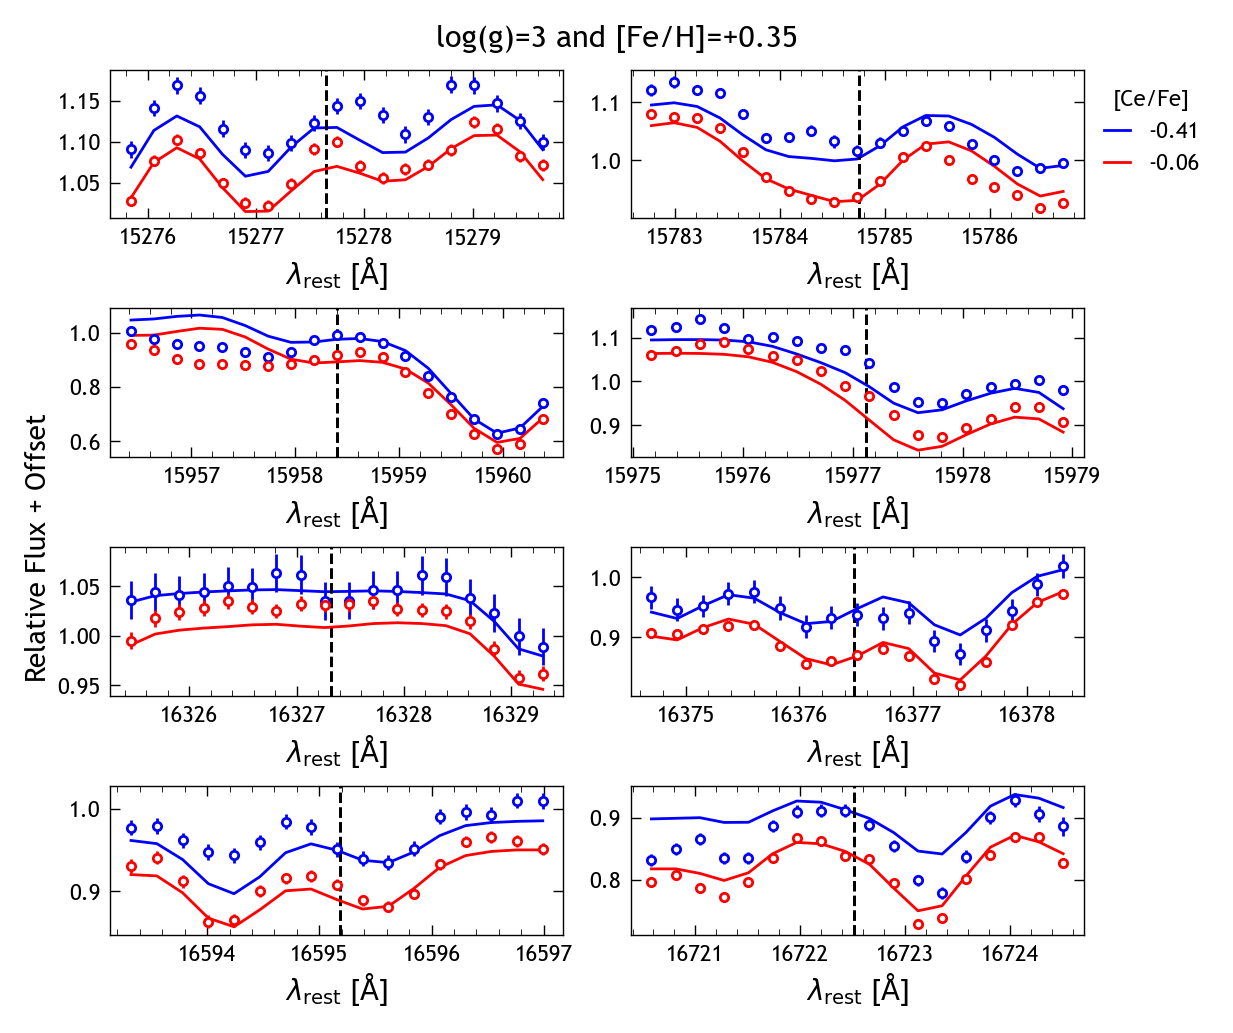

In [27]:
ce_ii_lines = [15277.65, 15784.75, 15958.40, 15977.12, 16327.32, 16376.48, 16595.18, 16722.51] # Angstroms, from Cunha+ (2017)

fig, axs = plt.subplots(4, 2, figsize=(6, 5), constrained_layout=True)
colors = ['b', 'r']
for j, sdss_id in enumerate(high_met_ids):
    mwmStar = mwmStar_list[j]
    aspcap = aspcap_list[j]
    wl_arr = vac2air(mwmStar['wavelength'][0])
    flux = mwmStar['flux'][0] / aspcap['continuum'][0]
    flux_err = mwmStar['ivar'][0]**-0.5 / aspcap['continuum'][0]
    flux_err = np.where(flux_err>1, np.nan, flux_err)
    model = aspcap['model_flux_ce_h'][0]
    cefe = aspcap['ce_h'][0] - aspcap['fe_h'][0]
    offset = j*-0.05
    print(mwmStar['snr'][0])
    for i, ax in enumerate(axs.flatten()):
        line = ce_ii_lines[i]
        ax.axvline(line, color='k', linestyle='--')
        wl_range = (line-2, line+2)
        mask = (wl_arr >= wl_range[0]) & (wl_arr < wl_range[1])
        ax.errorbar(
            wl_arr[mask], flux[mask]+offset, 
            yerr=flux_err[mask], 
            fmt='o', ms=3, mfc='w', capsize=0,
            color=colors[j]
        )
        ax.plot(
            wl_arr[mask], model[mask]+offset, 
            label=round(cefe, 2),
            color=colors[j]
        )
        ax.set_xlabel(r'$\lambda_{\rm rest}$ [${\rm \AA}$]')
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.xaxis.set_minor_locator(MultipleLocator(0.2))
        ax.ticklabel_format(style='plain', axis='x', useOffset=False)
axs[2,0].set_ylabel('Relative Flux + Offset', y=1)
fig.suptitle('log(g)=3 and [Fe/H]=+0.35')
axs[0,1].legend(title='[Ce/Fe]', bbox_to_anchor=(1,1), loc='upper left')
plt.show()

### Metal-poor

In [28]:
metal_poor_sample = mwm_sample[
    # (mwm_sample['fe_h'] >= -0.55) &
    (mwm_sample['fe_h'] < -0.8) &
    # (mwm_sample['mg_fe'] >= 0.0) &
    # (mwm_sample['mg_fe'] < 0.1) &
    (mwm_sample['logg'] >= 1.9) &
    (mwm_sample['logg'] < 2.1)
]
metal_poor_sample.sort_values('snr', inplace=True)
metal_poor_sample[['fe_h', 'ce_fe', 'snr']]

,fe_h,ce_fe,snr
sdss_id,,,
61074587,-1.347751,0.104071,100.108240
112946096,-1.165151,0.858461,100.312775
83804732,-0.931401,-0.192479,100.727325
62126288,-1.124151,0.011371,101.600160
109044699,-0.822391,-0.086289,102.301384
...,...,...,...
70155266,-1.005351,-0.012329,816.798950
70671827,-1.239651,-0.053629,928.726500
61604644,-0.993351,-0.037129,1030.897500


## SNR

### High logg, High [Ce/Fe]

In [29]:
high_cefe = mwm_sample[
    (mwm_sample['fe_h'] >= -0.05) &
    (mwm_sample['fe_h'] < 0.05) &
    # (mwm_sample['mg_fe'] >= -0.05) &
    # (mwm_sample['mg_fe'] < 0.05) &
    (mwm_sample['logg'] >= 2.9) &
    (mwm_sample['logg'] < 3.1) &
    (mwm_sample['ce_fe'] >= 0.3) &
    (mwm_sample['ce_fe'] < 0.5)
]
high_cefe.sort_values('snr', inplace=True)
high_cefe.snr

sdss_id
69244655     100.228264
68503681     101.632070
105450671    107.092890
55448257     108.164930
72651665     113.035675
115622726    113.684166
74707840     117.883770
65577614     118.098790
116472353    119.259580
72591913     128.239140
95779262     132.230710
69056190     133.285260
55378429     134.676850
116489317    134.996000
87476249     135.652970
66185168     136.275630
99028765     137.904830
72588679     142.787860
66196136     145.463270
107141783    147.703640
57958194     149.388410
77553925     150.679350
66756858     159.300140
101077569    165.763180
116364188    221.154920
65834340     232.364470
74175105     236.020340
74957447     248.461360
60483897     258.108150
116154021    332.154000
114516536    338.989930
55448710     367.709930
57535886     369.650760
74070543     374.041440
57800256     451.107300
65287397     503.771850
81655486     533.171000
60570991     566.824300
55921967     586.251900
87416270     770.049500
Name: snr, dtype: float64

In [30]:
high_cefe_ids = []
snr_bins = [100, 200, 500, 1000]
for i in range(len(snr_bins)-1):
    same_snr_cefe = high_cefe[
        (high_cefe['snr'] >= snr_bins[i]) &
        (high_cefe['snr'] < snr_bins[i+1])
    ]
    high_cefe_ids.append(same_snr_cefe.index[0])

print(high_cefe_ids)

[np.int64(69244655), np.int64(116364188), np.int64(65287397)]


In [31]:
# Download data
access.reset()
access.remote()
for sdss_id in high_cefe_ids:
    access.add('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)
    access.add('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=sdss_id)
access.set_stream()
access.commit()

Progress:   0%|          | 0/6 [00:00<?, ?files/s, n_files=6, n_streams=5]

SDSS_ACCESS> Done!


In [32]:
# Extract spectra
mwmStar_list = []
aspcap_list = []
for sdss_id in high_cefe_ids:
    mwmStar_filename = access.full('mwmStar', v_astra='0.6.0', component='', sdss_id=sdss_id)
    aspcap_filename = access.full('astraStarASPCAP', v_astra='0.6.0', component='', sdss_id=sdss_id)
    # Determine telescope / hdu entry
    if mwm_sample.loc[sdss_id].telescope == 'apo25m':
        hdu = 3
    else:
        hdu = 4
    # Read fits file
    mwmStar = Table.read(mwmStar_filename, hdu=hdu)
    mwmStar_list.append(mwmStar)
    aspcap = Table.read(aspcap_filename, hdu=hdu)
    aspcap_list.append(aspcap)

[WARNING]: /var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_49682/3042639599.py:11: RuntimeWarning: divide by zero encountered in power
  flux_err = mwmStar['ivar'][0]**-0.5 / aspcap['continuum'][0]



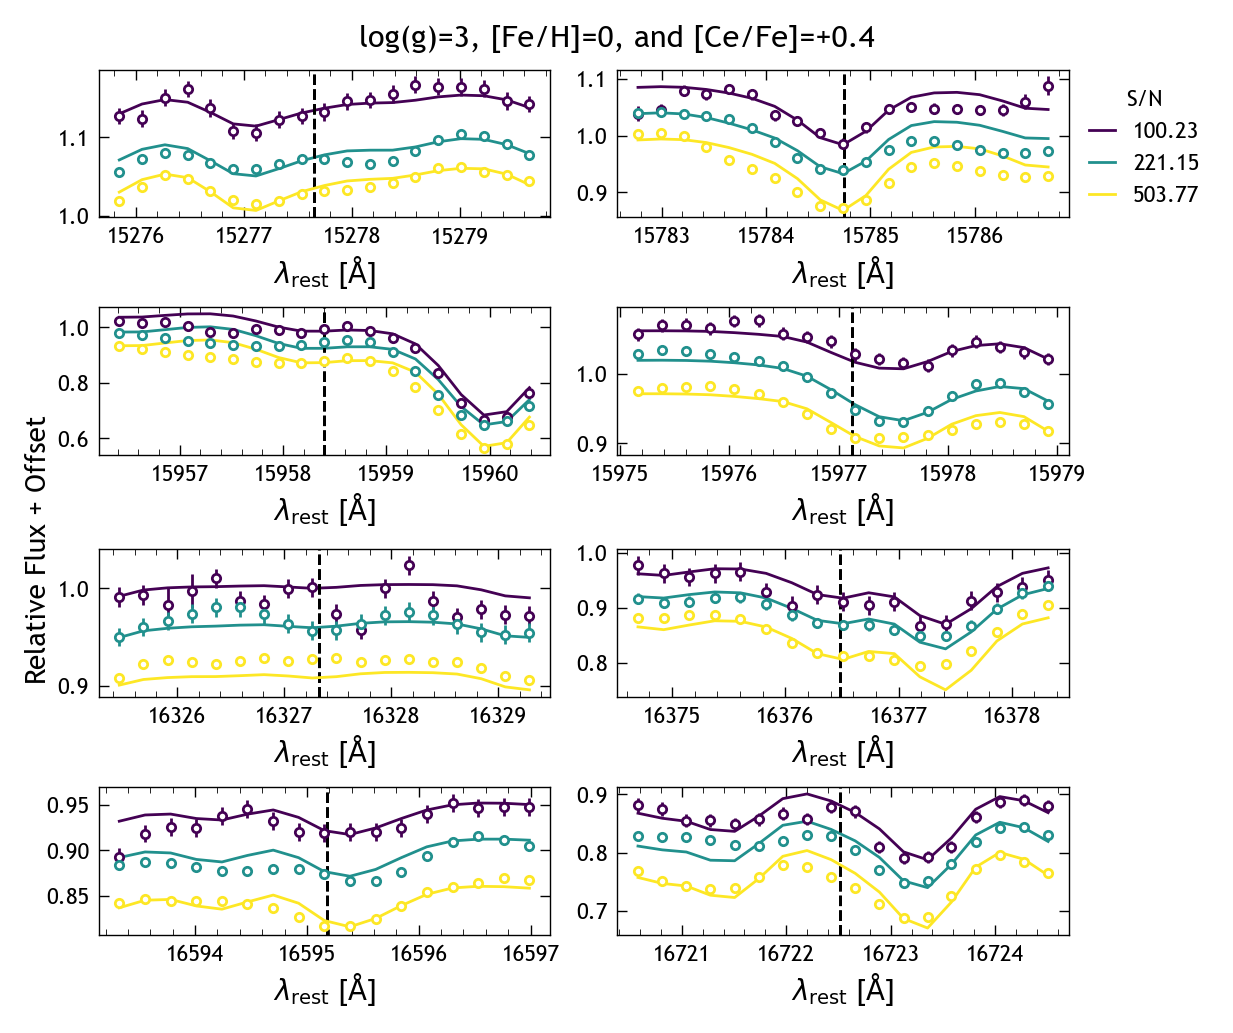

In [33]:
ce_ii_lines = [15277.65, 15784.75, 15958.40, 15977.12, 16327.32, 16376.48, 16595.18, 16722.51] # Angstroms, from Cunha+ (2017)

fig, axs = plt.subplots(4, 2, figsize=(6, 5), constrained_layout=True)
cmap = plt.get_cmap('viridis')
norm = BoundaryNorm(snr_bins, cmap.N)
for j, sdss_id in enumerate(high_cefe_ids):
    mwmStar = mwmStar_list[j]
    aspcap = aspcap_list[j]
    wl_arr = vac2air(mwmStar['wavelength'][0])
    flux = mwmStar['flux'][0] / aspcap['continuum'][0]
    flux_err = mwmStar['ivar'][0]**-0.5 / aspcap['continuum'][0]
    model = aspcap['model_flux_ce_h'][0]
    snr = mwm_sample.loc[sdss_id]['snr']
    offset = j*-0.05
    for i, ax in enumerate(axs.flatten()):
        line = ce_ii_lines[i]
        ax.axvline(line, color='k', linestyle='--')
        wl_range = (line-2, line+2)
        mask = (wl_arr >= wl_range[0]) & (wl_arr < wl_range[1])
        # if i == 0: 
        #     print(aspcap['continuum'][0][mask])
        #     print(aspcap['model_flux'][0][mask])
        #     print(aspcap['model_flux_fe_h'][0][mask])
        ax.errorbar(
            wl_arr[mask], flux[mask]+offset, 
            yerr=flux_err[mask], 
            fmt='o', ms=3, mfc='w', capsize=0,
            color=cmap(norm(snr))
        )
        ax.plot(
            wl_arr[mask], model[mask]+offset, 
            c=cmap(norm(snr)), 
            label=round(snr, 2)
        )
        ax.set_xlabel(r'$\lambda_{\rm rest}$ [${\rm \AA}$]')
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.xaxis.set_minor_locator(MultipleLocator(0.2))
        ax.ticklabel_format(style='plain', axis='x', useOffset=False)
axs[2,0].set_ylabel('Relative Flux + Offset', y=1)
fig.suptitle('log(g)=3, [Fe/H]=0, and [Ce/Fe]=+0.4')
axs[0,1].legend(title='S/N', bbox_to_anchor=(1,1), loc='upper left')
plt.show()